# CHƯƠNG 7: PHÂN TÍCH BIỆT SỐ VÀ HỒI QUY LOGISTIC

## 7.1. Tình huống dẫn dắt: Bài toán xếp hạng tín dụng và sự sụp đổ của hồi quy tuyến tính

Trong bối cảnh hệ thống tài chính bán lẻ phát triển với tốc độ chóng mặt, hoạt động quản trị rủi ro tín dụng tại các ngân hàng thương mại đang đối mặt với những thách thức vô cùng lớn. Hằng ngày, bộ phận thẩm định tín dụng phải tiếp nhận và xử lý hàng vạn hồ sơ đăng ký vay vốn từ khách hàng cá nhân. Mỗi quyết định phê duyệt cho vay đều mang tính quyết định đến sự tồn vong của ngân hàng: một quyết định từ chối sai lầm đối với khách hàng tốt sẽ làm mất đi cơ hội sinh lời từ lãi suất, nhưng một quyết định phê duyệt sai lầm đối với khách hàng xấu sẽ trực tiếp dẫn đến nợ xấu và tổn thất tài chính nghiêm trọng. Quy trình thẩm định thủ công truyền thống dựa trên kinh nghiệm của các chuyên viên tín dụng đã chứng minh sự lỗi thời vì tính chủ quan cao, tốc độ xử lý chậm chạp và không thể đáp ứng được quy mô giao dịch khổng lồ của kỷ nguyên số. Do đó, nhu cầu xây dựng các hệ thống xếp hạng tín dụng tự động (Credit Scoring) dựa trên các mô hình thống kê định lượng đã trở thành một đòi hỏi sống còn.

Để xây dựng một cỗ máy tự động đánh giá hồ sơ vay, nhóm phân tích dữ liệu của ngân hàng thu thập các thông tin lịch sử của những khách hàng đã từng vay vốn trong quá khứ, bao gồm độ tuổi, thu nhập hằng năm, điểm số tín dụng từ trung tâm thông tin tín dụng, tỷ lệ nợ trên thu nhập, và số lượng người phụ thuộc. Biến số mục tiêu cần dự báo là một biến số nhị phân chỉ nhận hai giá trị duy nhất: giá trị một đại diện cho việc khách hàng vỡ nợ hoặc chậm trả nợ trong vòng hai năm tiếp theo, và giá trị không đại diện cho việc khách hàng hoàn trả đầy đủ gốc và lãi đúng hạn. Đây chính là bài toán phân loại nhị phân điển hình trong phân tích đa biến kinh tế.

Khi tiếp cận bài toán phân loại nhị phân này, xu hướng tự nhiên của một nhà phân tích mới bắt đầu là sử dụng mô hình hồi quy tuyến tính bội sử dụng phương pháp bình phương tối thiểu thông thường (OLS) đã được học ở Chương 6, còn được gọi là Mô hình Xác suất Tuyến tính (Linear Probability Model - LPM). Dưới cách tiếp cận này, chúng ta xem xét biến phụ thuộc nhị phân như một biến số liên tục thông thường và chạy hồi quy OLS để dự báo xác suất vỡ nợ của khách hàng. Tuy nhiên, khi nhóm phân tích chạy thử nghiệm mô hình LPM trên dữ liệu thực tế, họ nhanh chóng nhận ra rằng mô hình hồi quy tuyến tính bội OLS sụp đổ hoàn toàn và đưa ra các kết quả phi lý về mặt toán học lẫn thực tiễn kinh doanh.

Điểm yếu chí mạng thứ nhất của mô hình xác suất tuyến tính LPM là các giá trị dự báo có thể nằm ngoài khoảng giới hạn từ không đến một. Về mặt định nghĩa xác suất học, xác suất xảy ra một sự kiện bắt buộc phải nằm trong dải đóng từ không phần trăm đến một trăm phần trăm. Nhưng do mô hình OLS là một hàm tuyến tính kéo dài vô tận, đối với những khách hàng có hồ sơ tài chính cực tốt (thu nhập rất cao và điểm tín dụng xuất sắc), mô hình LPM có thể đưa ra mức dự báo xác suất vỡ nợ mang giá trị âm, chẳng hạn như âm không phẩy hai mươi. Ngược lại, đối với những khách hàng có rủi ro cực cao, mô hình có thể dự báo xác suất vỡ nợ vượt quá một, ví dụ như một phẩy mười lăm. Các con số dự báo này hoàn toàn vô nghĩa về mặt toán học và không thể giải thích được cho ban giám đốc rủi ro để đưa ra quyết định duyệt vay thực tế.

Điểm yếu thứ hai là vi phạm nghiêm trọng giả định về phương sai đồng nhất của sai số ngẫu nhiên trong định lý Gauss-Markov. Do biến phụ thuộc chỉ nhận hai giá trị không hoặc một, sai số ngẫu nhiên của mô hình tại mỗi điểm quan sát không còn tuân theo phân phối chuẩn liên tục. Để chứng minh điều này bằng toán học, gọi $P_i$ là xác suất vỡ nợ thực tế của khách hàng thứ $i$. Biến phụ thuộc $y_i$ nhận giá trị bằng một với xác suất $P_i$, và nhận giá trị bằng không với xác suất $1-P_i$. Sai số ngẫu nhiên $\varepsilon_i = y_i - P_i$ khi đó chỉ có thể nhận hai giá trị: giá trị $1 - P_i$ với xác suất $P_i$, hoặc giá trị $-P_i$ với xác suất $1-P_i$. Phương sai của sai số ngẫu nhiên $\varepsilon_i$ được tính toán cụ thể theo công thức:

$$\text{Var}(\varepsilon_i) = (1 - P_i)^2 P_i + (-P_i)^2 (1 - P_i) = P_i (1 - P_i)$$

Do xác suất $P_i$ là một hàm phụ thuộc trực tiếp vào các biến độc lập của khách hàng, phương sai của sai số ngẫu nhiên $\text{Var}(\varepsilon_i)$ sẽ thay đổi theo từng quan sát. Hiện tượng phương sai sai số thay đổi cực đoan này vi phạm giả định phương sai đồng nhất, làm vô hiệu hóa các công thức tính sai số chuẩn thông thường của OLS, khiến các phép kiểm định giả thuyết thống kê t-test và F-test trở nên chệch và không còn đáng tin cậy.

Điểm yếu thứ ba là tính phi thực tế của giả định tác động tuyến tính hằng số. Mô hình LPM giả định rằng việc tăng thêm một triệu đồng thu nhập hoặc tăng thêm một điểm tín dụng luôn có tác động làm giảm xác suất vỡ nợ với một lượng cố định như nhau, bất kể điểm xuất phát của khách hàng là bao nhiêu. Trong thực tế hành vi tài chính, tác động này có tính chất phi tuyến tính rõ rệt theo đường cong chữ S. Khi một khách hàng có điểm tín dụng rất thấp ở mức bốn trăm, việc tăng thêm một trăm điểm lên mức năm trăm sẽ tạo ra sự cải thiện rủi ro vô cùng lớn. Nhưng khi một khách hàng đã có điểm tín dụng xuất sắc ở mức bảy trăm năm mươi, việc tăng thêm một trăm điểm lên mức tám trăm năm mươi hầu như không làm thay đổi xác suất vỡ nợ vốn đã tiệm cận về không của họ. Mô hình tuyến tính thẳng tắp của OLS hoàn toàn bất lực trong việc nắm bắt hành vi phi tuyến tính sinh động này.

Hơn thế nữa, do giá trị dự báo $\hat{y}_i$ của mô hình LPM là các giá trị liên tục, để ra quyết định duyệt vay nhị phân, nhà phân tích bắt buộc phải lựa chọn một điểm cắt (threshold) nhân tạo, thông thường là không phẩy năm mươi, để phân loại. Nếu $\hat{y}_i \ge 0.50$, khách hàng bị xếp vào nhóm rủi ro cao và ngược lại. Tuy nhiên, việc áp đặt điểm cắt này lên một dải dự báo không bị giới hạn sẽ tạo ra những kết quả phân loại cực kỳ không ổn định. Việc dịch chuyển nhỏ của điểm cắt sẽ làm thay đổi hoàn toàn cơ cấu phê duyệt tín dụng của ngân hàng, gây khó khăn cho việc quản trị rủi ro và tối ưu hóa lợi nhuận.

Để vượt qua những bế tắc toán học của mô hình OLS và xây dựng một hệ thống chấm điểm tín dụng chuẩn mực, chúng ta cần dịch chuyển tư duy sang các phương pháp phân loại chuyên biệt được thiết kế riêng cho biến phụ thuộc định danh. Trong hệ thống phân loại đa biến của Hair et al. (2018), đây chính là sứ mệnh của Phân tích Biệt số (Discriminant Analysis) và Hồi quy Logistic (Logistic Regression). Các kỹ thuật này không cố gắng ép dữ liệu nhị phân vào một đường thẳng vô hạn, mà sử dụng các phép biến đổi toán học thông minh để bóp các giá trị dự báo nằm trọn vẹn trong dải xác suất từ không đến một, đồng thời mô hình hóa chính xác các đường cong chữ S phi tuyến tính của hành vi con người. Bằng cách làm chủ các thuật toán phân loại này trong chương này, nhà phân tích sẽ xây dựng được một cỗ máy duyệt vay tự động vững chắc, làm tiền đề cho việc tối ưu hóa lợi nhuận và quản trị rủi ro hệ thống của ngân hàng bán lẻ.

## 7.2. Discriminant Analysis (Linear Discriminant Analysis - LDA)

Để phân loại các quan sát vào các nhóm định danh dựa trên một tập hợp các đặc trưng liên tục, Discriminant Analysis (Linear Discriminant Analysis - LDA) đại diện cho phương pháp tiếp cận cổ điển và có hệ thống hình học vô cùng sâu sắc. Được phát triển ban đầu bởi nhà thống kê lỗi lạc Ronald Fisher vào năm một nghìn chín trăm ba mươi sáu, phương pháp này tìm cách chiếu không gian dữ liệu nhiều chiều xuống một không gian có số chiều thấp hơn sao cho sự phân tách giữa các nhóm là lớn nhất trong khi sự phân tán trong nội bộ nhóm là nhỏ nhất. Trong kỷ nguyên khoa học dữ liệu hiện đại, mặc dù có sự xuất hiện của nhiều thuật toán học máy phức tạp, Discriminant Analysis vẫn giữ nguyên giá trị cốt lõi nhờ tính minh bạch cao về mặt toán học, khả năng giải thích cấu trúc hình học của dữ liệu, và hiệu năng dự báo xuất sắc khi các giả định thống kê được thỏa mãn đầy đủ. Kỹ thuật này không chỉ đóng vai trò là một mô hình phân loại nhị phân hay đa phân lớp hiệu quả, mà còn được sử dụng rộng rãi như một phương pháp giảm chiều dữ liệu có giám sát, giúp giữ lại các thông tin phân lớp quan trọng nhất trước khi tiến hành các phân tích chuyên sâu tiếp theo trong chuỗi xử lý dữ liệu đa biến.

### 7.2.1. Cơ chế hình học và toán học của LDA

Ý tưởng hình học cốt lõi của Discriminant Analysis là tìm kiếm một vector chiếu, ký hiệu là $\mathbf{w}$, để thực hiện phép chiếu các điểm dữ liệu nhiều chiều lên một đường thẳng hoặc siêu phẳng có số chiều thấp hơn. Để hình dung một cách trực quan trong không gian hai chiều, hãy tưởng tượng chúng ta có hai nhóm khách hàng phân tán trên một đồ thị phân tán với hai trục là thu nhập hằng năm và tỷ lệ nợ trên thu nhập. Hai nhóm này có mức độ chồng lấn khá lớn nếu chúng ta chỉ chiếu các điểm dữ liệu lên trục thu nhập hoặc chỉ chiếu lên trục tỷ lệ nợ, nghĩa là phân tích đơn biến sẽ hoàn toàn thất bại trong việc phân tách họ. Tuy nhiên, nếu chúng ta tìm được một đường thẳng nghiêng phù hợp và chiếu tất cả các điểm dữ liệu lên đường thẳng đó, hình chiếu của hai nhóm khách hàng sẽ tách biệt hoàn toàn nhau mà không bị chồng lấn. LDA chính là công cụ toán học giúp xác định chính xác góc nghiêng tối ưu của đường thẳng chiếu này. Sau phép chiếu này, chúng ta mong muốn các điểm thuộc cùng một nhóm sẽ tụ hội lại thật chặt chẽ xung quanh tâm nhóm của chúng, trong khi tâm của các nhóm khác nhau sẽ bị đẩy ra xa nhau nhất có thể.

Để xây dựng cơ cấu toán học của phép chiếu này đối với kịch bản hai nhóm, gọi $y_i = \mathbf{w}^T \mathbf{x}_i$ là tọa độ của điểm dữ liệu $\mathbf{x}_i$ sau khi chiếu lên đường thẳng. Kỳ vọng trung bình của các điểm chiếu thuộc nhóm một và nhóm hai lần lượt được xác định theo các công thức:

$$\tilde{\mu}_1 = \mathbf{w}^T \boldsymbol{\mu}_1$$

$$\tilde{\mu}_2 = \mathbf{w}^T \boldsymbol{\mu}_2$$

Trong đó, $\boldsymbol{\mu}_1$ và $\boldsymbol{\mu}_2$ là các vector trung bình thực tế của hai nhóm trong không gian gốc nhiều chiều. Sự khác biệt giữa các trung bình nhóm sau khi chiếu được đo lường bằng bình phương khoảng cách của chúng:

$$(\tilde{\mu}_1 - \tilde{\mu}_2)^2 = (\mathbf{w}^T (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2))^2 = \mathbf{w}^T \mathbf{S}_B \mathbf{w}$$

Trong biểu thức này, $\mathbf{S}_B = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T$ đại diện cho ma trận tán xạ giữa hai nhóm. Ma trận này phản ánh sự phân tán giữa các nhóm với nhau và có cấu trúc đối xứng, nửa xác định dương. Đồng thời, độ phân tán trong nội bộ từng nhóm sau khi chiếu được đo lường bằng tổng bình phương sai lệch của các điểm chiếu xung quanh trung bình nhóm tương ứng:

$$\tilde{s}_1^2 = \sum_{i \in C_1} (y_i - \tilde{\mu}_1)^2 = \mathbf{w}^T \mathbf{S}_1 \mathbf{w}$$

$$\tilde{s}_2^2 = \sum_{i \in C_2} (y_i - \tilde{\mu}_2)^2 = \mathbf{w}^T \mathbf{S}_2 \mathbf{w}$$

Trong đó, $\mathbf{S}_1$ và $\mathbf{S}_2$ là các ma trận tán xạ thực tế của riêng nhóm một và nhóm hai trong không gian gốc, phản ánh sự biến động nội tại của từng nhóm dữ liệu riêng biệt. Tổng độ phân tán trong các nhóm sau khi chiếu được tính bằng $\tilde{s}_1^2 + \tilde{s}_2^2 = \mathbf{w}^T \mathbf{S}_W \mathbf{w}$, với $\mathbf{S}_W = \mathbf{S}_1 + \mathbf{S}_2$ là ma trận tán xạ trong nhóm gộp. Fisher giới thiệu chỉ số tiêu chuẩn tối ưu hóa, được gọi là tiêu chuẩn Fisher (Fisher's criterion), ký hiệu là $J(\mathbf{w})$, được định nghĩa bằng tỷ số giữa bình phương khoảng cách hai tâm nhóm và tổng độ phân tán trong các nhóm sau khi chiếu:

$$J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

Chỉ số tiêu chuẩn này phản ánh một nguyên lý trực quan trong thiết kế phân loại: chúng ta muốn khoảng cách giữa các nhóm sau khi chiếu càng lớn càng tốt (tử số lớn) và độ biến động nội bộ từng nhóm sau khi chiếu càng nhỏ càng tốt (mẫu số nhỏ). Để tìm vector chiếu $\mathbf{w}$ tối ưu hóa tiêu chuẩn Fisher $J(\mathbf{w})$, chúng ta tiến hành lấy đạo hàm riêng theo $\mathbf{w}$ và thiết lập kết quả bằng không:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{2 \mathbf{S}_B \mathbf{w} (\mathbf{w}^T \mathbf{S}_W \mathbf{w}) - 2 \mathbf{S}_W \mathbf{w} (\mathbf{w}^T \mathbf{S}_B \mathbf{w})}{(\mathbf{w}^T \mathbf{S}_W \mathbf{w})^2} = \mathbf{0}$$

Biểu thức này dẫn đến điều kiện cân bằng:

$$\mathbf{S}_B \mathbf{w} = \left( \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}} \right) \mathbf{S}_W \mathbf{w} = J(\mathbf{w}) \mathbf{S}_W \mathbf{w}$$

Nếu ma trận tán xạ trong nhóm $\mathbf{S}_W$ khả nghịch, chúng ta có thể nhân cả hai vế với ma trận nghịch đảo $\mathbf{S}_W^{-1}$ để chuyển đổi về bài toán tìm giá trị riêng chuẩn tắc:

$$\mathbf{S}_W^{-1} \mathbf{S}_B \mathbf{w} = J(\mathbf{w}) \mathbf{w}$$

Để giải phương trình này một cách cụ thể đối với kịch bản hai nhóm, chúng ta nhận thấy rằng vector $\mathbf{S}_B \mathbf{w} = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \mathbf{w}$. Vì tích vô hướng $(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \mathbf{w}$ là một hằng số vô hướng, ký hiệu là $c$, chúng ta có thể viết $\mathbf{S}_B \mathbf{w} = c (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$. Thế mối liên hệ này vào phương trình giá trị riêng, chúng ta thu được:

$$J(\mathbf{w}) \mathbf{S}_W \mathbf{w} = c (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) \implies \mathbf{w} = \frac{c}{J(\mathbf{w})} \mathbf{S}_W^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$$

Do chiều hướng của vector chiếu là yếu tố quyết định duy nhất đối với phép phân loại, chúng ta có thể bỏ qua hằng số nhân và thiết lập lời giải tối ưu cho vector chiếu dưới dạng công thức cụ thể:

$$\mathbf{w} \propto \mathbf{S}_W^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$$

Công thức này chỉ ra rằng hướng chiếu tối ưu được xác định bằng hiệu của hai vector trung bình nhóm, được điều chỉnh tỷ lệ và hướng bằng cách nhân với ma trận nghịch đảo của ma trận tán xạ trong nhóm. Việc nhân với $\mathbf{S}_W^{-1}$ đóng vai trò vô cùng quan trọng: nó giúp khử tương quan và chuẩn hóa phương sai giữa các đặc trưng dữ liệu. Nếu các đặc trưng hoàn toàn độc lập và không tương quan, hướng chiếu đơn giản là hướng nối giữa hai tâm nhóm. Nhưng khi các đặc trưng có tương quan chéo mạnh mẽ, ma trận $\mathbf{S}_W^{-1}$ sẽ chủ động xoay hướng chiếu để tránh các vùng dữ liệu bị chồng lấn do tương quan chéo, mang lại khả năng phân loại vượt trội so với phép chiếu trực giao thông thường.

Khi mở rộng bài toán phân tích biệt số cho tình huống đa nhóm, nghĩa là số lượng nhóm $g$ lớn hơn hai, cơ chế toán học của Fisher được khái quát hóa thông qua Phân tích Biệt số Đa nhóm (Multiple Discriminant Analysis - MDA). Trong bối cảnh đa nhóm, chúng ta cần tìm một không gian chiếu có số chiều là $k = \min(g-1, p)$ thay vì chỉ một chiều duy nhất. Ma trận tán xạ giữa các nhóm $\mathbf{S}_B$ được định nghĩa lại bằng cách đo lường khoảng cách từ các tâm nhóm đến tâm toàn cục của toàn bộ dữ liệu, ký hiệu là $\boldsymbol{\mu}$:

$$\mathbf{S}_B = \sum_{g=1}^G n_g (\boldsymbol{\mu}_g - \boldsymbol{\mu})(\boldsymbol{\mu}_g - \boldsymbol{\mu})^T$$

Trong đó, $n_g$ là quy mô mẫu của nhóm $g$, và $\boldsymbol{\mu}_g$ là vector trung bình của nhóm $g$. Ma trận tán xạ trong nhóm $\mathbf{S}_W$ được tính bằng tổng của tất cả các ma trận tán xạ nội bộ nhóm:

$$\mathbf{S}_W = \sum_{g=1}^G \sum_{i \in C_g} (\mathbf{x}_i - \boldsymbol{\mu}_g)(\mathbf{x}_i - \boldsymbol{\mu}_g)^T$$

Mục tiêu của MDA là tìm một ma trận chuyển đổi tuyến tính $\mathbf{W}$ để tối ưu hóa tỷ số định thức, phản ánh tiêu chuẩn Fisher trong không gian nhiều chiều:

$$J(\mathbf{W}) = \frac{|\mathbf{W}^T \mathbf{S}_B \mathbf{W}|}{|\mathbf{W}^T \mathbf{S}_W \mathbf{W}|}$$

Lời giải của bài toán tối ưu hóa này thu được bằng cách thực hiện phân tích trị riêng cho ma trận $\mathbf{S}_W^{-1} \mathbf{S}_B$. Các cột của ma trận $\mathbf{W}$ chính là các vector riêng ứng với các trị riêng lớn nhất của ma trận này. Các vector riêng này được gọi là các hàm biệt số chính tắc (canonical discriminant functions). Trị riêng tương ứng phản ánh tỷ lệ phương sai giữa các nhóm mà hàm biệt số đó giải thích được. Bằng cách chiếu dữ liệu lên các hàm biệt số này, chúng ta có thể trực quan hóa toàn bộ dữ liệu nhiều chiều trên một không gian hai chiều hoặc ba chiều để quan sát cấu trúc tách biệt giữa các nhóm, đồng thời thực hiện phân loại các quan sát mới vào nhóm có khoảng cách Mahalanobis gần nhất trong không gian biệt số.

### 7.2.2. Các giả định thống kê và Hàm phân biệt

Để các hàm biệt số thu được từ thuật toán LDA đạt hiệu năng tối ưu và có ý nghĩa kiểm định thống kê đáng tin cậy, dữ liệu phân tích phải thỏa mãn các giả định nền tảng của lý thuyết thống kê đa biến. Giả định thứ nhất yêu cầu các biến đặc trưng giải thích trong từng nhóm phải tuân theo phân phối chuẩn đa biến. Điều này nghĩa là tại mỗi nhóm, sự kết hợp ngẫu nhiên của các đặc trưng tạo thành một phân phối có hình chuông nhiều chiều ổn định. Giả định thứ hai, cực kỳ quan trọng và nhạy cảm, yêu cầu ma trận hiệp phương sai của các đặc trưng phải đồng nhất và bằng nhau giữa tất cả các nhóm, nghĩa là $\boldsymbol{\Sigma}_1 = \boldsymbol{\Sigma}_2 = \ldots = \boldsymbol{\Sigma}_g = \boldsymbol{\Sigma}$. Giả định thứ ba đòi hỏi các quan sát mẫu phải được thu thập độc lập với nhau, tránh hiện tượng tự tương quan giữa các đối tượng phân tích.

Để kiểm định giả định đồng nhất ma trận hiệp phương sai trên thực tế dữ liệu đa biến, chúng ta sử dụng phép kiểm định Box's M (Box's M test). Giả thuyết không của phép kiểm định này phát biểu rằng các ma trận hiệp phương sai của các nhóm bằng nhau trong tổng thể. Chỉ số kiểm định Box's M được tính toán dựa trên định thức của các ma trận hiệp phương sai nhóm và ma trận hiệp phương sai gộp, ký hiệu là $\mathbf{S}_{pooled}$:

$$M = (n - g) \ln |\mathbf{S}_{pooled}| - \sum_{g=1}^G (n_g - 1) \ln |\mathbf{S}_g|$$

Trong đó, $\mathbf{S}_g$ là ma trận hiệp phương sai mẫu của nhóm $g$, và $\mathbf{S}_{pooled}$ được tính bằng trung bình trọng số của các ma trận hiệp phương sai nhóm. Tuy nhiên, một lưu ý cực kỳ quan trọng là phép kiểm định Box's M vô cùng nhạy cảm với các vi phạm đối với giả định phân phối chuẩn đa biến. Nếu dữ liệu không tuân theo phân phối chuẩn, phép kiểm định này có xu hướng đưa ra kết luận bác bỏ giả thuyết đồng nhất phương sai ngay cả khi ma trận hiệp phương sai thực tế của các nhóm không có sự khác biệt lớn. Do đó, trong thực tế phân tích tài chính, khi kích thước mẫu lớn, nhà nghiên cứu thường sử dụng mức ý nghĩa vô cùng nhỏ như một phần nghìn để đưa ra kết luận bác bỏ, hoặc bổ sung bằng các đánh giá đồ thị trực quan.

Khi dữ liệu thỏa mãn các giả định này, chúng ta có thể xây dựng các hàm phân biệt tuyến tính Fisher hoặc các hàm phân biệt tuyến tính Bayes dựa trên tỷ số khả nhiên. Điểm biệt số (discriminant score) của một quan sát được tính toán bằng tổ hợp tuyến tính của các biến đặc trưng:

$$Z = w_0 + w_1 X_1 + w_2 X_2 + \ldots + w_p X_p$$

Trong đó, $w_0$ là hằng số phân biệt, và các hệ số $w_j$ đại diện cho trọng số biệt số của từng biến đặc trưng, phản ánh đóng góp đóng vai trò tương đối của biến đó trong việc phân tách các nhóm sau khi đã kiểm soát tương quan với các biến khác. Để phân loại một quan sát mới, chúng ta tính toán điểm $Z$ của nó và so sánh với một giá trị cắt tối ưu. Đối với tình huống hai nhóm có quy mô bằng nhau và chi phí phân loại sai đồng đều, điểm cắt này chính là trung điểm của điểm số trung bình của hai nhóm sau phép chiếu:

$$Z_{cutoff} = \frac{\bar{Z}_1 + \bar{Z}_2}{2}$$

Nếu điểm số $Z$ của quan sát vượt qua giá trị cắt, nó sẽ được xếp vào nhóm một, và ngược lại sẽ được phân vào nhóm không. Trong tình huống quy mô mẫu của hai nhóm có sự chênh lệch lớn trong thực tế, điểm cắt sẽ được điều chỉnh bằng cách cộng thêm số hạng hiệu chỉnh dựa trên xác suất tiền nghiệm của các nhóm:

$$Z_{cutoff\_adjusted} = Z_{cutoff} + \ln \left( \frac{P(C_2)}{P(C_1)} \right)$$

Trong thực tế phân tích dữ liệu tài chính và hành vi kinh tế, giả định về tính đồng nhất của ma trận hiệp phương sai giữa các nhóm thường xuyên bị vi phạm do các nhóm có mức độ phân tán hành vi rất khác nhau. Ví dụ, trong bài toán xếp hạng tín dụng, nhóm khách hàng hoàn trả nợ đúng hạn thường tập trung rất chặt chẽ xung quanh các chỉ số tài chính ổn định (phương sai nhỏ), trong khi nhóm khách hàng vỡ nợ lại có sự phân tán hành vi cực kỳ rộng và bất định (phương sai rất lớn). Khi giả định đồng nhất hiệp phương sai bị vi phạm nghiêm trọng, việc áp dụng ranh giới phân tách tuyến tính của LDA sẽ dẫn đến sai số phân loại lớn ở các vùng biên.

Để giải quyết bài toán này, chúng ta phải chuyển sang áp dụng Phân tích Biệt số Bậc hai (Quadratic Discriminant Analysis - QDA). Thuật toán QDA cho phép mỗi nhóm sở hữu một ma trận hiệp phương sai $\boldsymbol{\Sigma}_g$ riêng biệt, phản ánh chính xác cấu trúc phân tán đặc thù của từng nhóm. Hàm phân biệt bậc hai cho từng nhóm $g$ được thiết lập dựa trên mật độ phân phối chuẩn đa biến theo công thức:

$$d_g(\mathbf{x}) = -\frac{1}{2} \ln |\boldsymbol{\Sigma}_g| - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_g)^T \boldsymbol{\Sigma}_g^{-1} (\mathbf{x} - \boldsymbol{\mu}_g) + \ln P(C_g)$$

Trong đó, $|\boldsymbol{\Sigma}_g|$ là định thức của ma trận hiệp phương sai nhóm $g$, và $P(C_g)$ là xác suất tiền nghiệm của nhóm đó. Do ma trận nghịch đảo $\boldsymbol{\Sigma}_g^{-1}$ thay đổi theo từng nhóm, số hạng bậc hai $\mathbf{x}^T \boldsymbol{\Sigma}_g^{-1} \mathbf{x}$ không bị triệt tiêu khi so sánh hiệu hàm phân biệt giữa các nhóm, tạo nên ranh giới phân tách giữa các nhóm là các đường cong bậc hai (quadratic boundaries) vô cùng linh hoạt như parabol hay hyperbol. Tuy thế, sự linh hoạt này đi kèm với một cái giá phải trả rất lớn về độ phức tạp tính toán và dung lượng mẫu: QDA đòi hỏi phải ước lượng riêng biệt $g$ ma trận hiệp phương sai, nghĩa là số lượng tham số cần ước lượng tăng lên theo cấp số nhân với số lượng biến đặc trưng. Cụ thể, số tham số cần ước lượng cho ma trận hiệp phương sai là $g \times p(p+1)/2$. Nếu số lượng biến đặc trưng lớn và kích thước mẫu của nhóm thiểu số nhỏ, QDA rất dễ rơi vào tình trạng Overfitting dữ liệu, khiến hiệu năng dự báo trên dữ liệu thực tế ngoài mẫu bị suy giảm nghiêm trọng.

Ngoài ra, nhà phân tích thường xuyên đặt câu hỏi so sánh giữa Discriminant Analysis LDA và Mô hình Hồi quy Logistic. LDA đóng vai trò là một mô hình sinh (generative model), hoạt động bằng cách mô hình hóa phân phối xác suất có điều kiện của các đặc trưng trong từng nhóm $P(X|Y)$ kết hợp với xác suất tiền nghiệm để suy ra xác suất hậu nghiệm $P(Y|X)$ thông qua định lý Bayes. Ngược lại, Hồi quy Logistic là một mô hình phân biệt (discriminative model), tập trung ước lượng trực tiếp xác suất có điều kiện $P(Y|X)$ mà không cần quan tâm đến phân phối của các biến độc lập $X$. 

Do đó, hồi quy Logistic có ưu thế vượt trội về tính bền vững khi dữ liệu vi phạm giả định phân phối chuẩn hoặc khi chứa các biến giải thích dạng định tính nhị phân. Hơn thế nữa, thuật toán LDA sử dụng các giá trị trung bình nhóm và ma trận hiệp phương sai gộp để tính toán tham số, vốn là các chỉ số thống kê chịu tác động rất lớn bởi các điểm dữ liệu Outliers. Một vài quan sát Outliers cực đoan nằm xa ranh giới phân lớp có thể kéo lệch hoàn toàn tâm nhóm của LDA, làm méo mó ranh giới phân tách. 

Ngược lại, mô hình hồi quy Logistic sử dụng phương pháp ước lượng khả năng cực đại tập trung tối ưu hóa xác suất phân loại xung quanh ranh giới quyết định, do đó nó có độ bền vững rất cao đối với các điểm Outliers nằm xa biên giới phân lớp. Tuy nhiên, nếu dữ liệu thỏa mãn hoàn hảo các giả định chuẩn đa biến và đồng nhất phương sai, thuật toán LDA sẽ đạt hiệu quả sử dụng thông tin cao hơn, mang lại ranh giới phân loại chính xác hơn với cỡ mẫu nhỏ hơn, đồng thời hoạt động cực kỳ ổn định đối với các bài toán phân loại đa nhóm (nhiều hơn hai nhóm). Việc thấu hiểu sự khác biệt này giúp nhà phân tích lựa chọn công cụ phù hợp nhất cho từng bối cảnh dữ liệu thực tế.

Trong quá trình xây dựng và đánh giá các mô hình phân tích dữ liệu đa biến, một trong những thách thức cốt lõi là đảm bảo tính vững (robustness) và khả năng tổng quát hóa (generalizability) của mô hình ngoài mẫu (out-of-sample). Việc chỉ dựa vào các chỉ số đo lường mức độ phù hợp trên tập dữ liệu huấn luyện (training set) thường dẫn đến những kết luận sai lệch do hiện tượng học vẹt các nhiễu ngẫu nhiên. Để giải quyết triệt để vấn đề này, các nhà nghiên cứu cần áp dụng một hệ thống đánh giá đa chiều, kết hợp giữa nền tảng lý thuyết vững chắc và các kỹ thuật mô phỏng dữ liệu hiện đại. Cụ thể, trước khi tiến hành bất kỳ suy diễn thống kê nào, việc rà soát kỹ lưỡng các giả định cơ bản như tính phân phối chuẩn đa biến, tính đồng nhất của ma trận hiệp phương sai, và sự vắng mặt của hiện tượng Multicollinearity là điều kiện tiên quyết. Nếu các giả định này bị vi phạm nghiêm trọng mà không có biện pháp khắc phục, chẳng hạn như sử dụng các ước lượng mạnh (robust estimators) hoặc chuyển đổi biến số, các giá trị p-value và khoảng tin cậy thu được sẽ hoàn toàn mất đi ý nghĩa thống kê. Hơn nữa, việc lựa chọn mô hình không nên chỉ dừng lại ở việc tối ưu hóa một hàm mục tiêu toán học tĩnh. Cần phải đưa mô hình vào các kịch bản Cross-validation (Cross-validation) khắt khe, nơi dữ liệu được chia cắt ngẫu nhiên nhiều lần để kiểm tra sự ổn định của các hệ số ước lượng. Trong kỷ nguyên của khoa học dữ liệu, sự giao thoa giữa các phương pháp kinh tế lượng truyền thống và học máy hiện đại đang mở ra những hướng tiếp cận mới. Trong khi kinh tế lượng đề cao khả năng giải thích (interpretability) và suy luận nhân quả thông qua việc kiểm soát chặt chẽ các biến nhiễu, thì học máy lại ưu tiên tối đa hóa độ chính xác dự báo thông qua các cấu trúc hàm phức tạp và kỹ thuật Regularization. Tuy nhiên, ranh giới này đang dần mờ đi khi các kỹ thuật Explainable AI - XAI (Explainable AI - XAI) ra đời, cho phép chúng ta bóc tách cơ chế bên trong của những hộp đen thuật toán. Dù sử dụng phương pháp nào, người làm phân tích phải luôn giữ tư duy phản biện, liên tục đặt câu hỏi về nguồn gốc sinh dữ liệu (Data Generating Process) và không bao giờ đánh đổi sự hiểu biết về bản chất kinh tế của vấn đề lấy những cải thiện nhỏ nhặt về mặt sai số toán học. Việc kết hợp hài hòa giữa toán học chặt chẽ và tư duy nghiệp vụ sắc bén chính là chìa khóa để tạo ra những mô hình phân tích thực sự mang lại giá trị thực tiễn.

Trong quá trình xây dựng và đánh giá các mô hình phân tích dữ liệu đa biến, một trong những thách thức cốt lõi là đảm bảo tính vững (robustness) và khả năng tổng quát hóa (generalizability) của mô hình ngoài mẫu (out-of-sample). Việc chỉ dựa vào các chỉ số đo lường mức độ phù hợp trên tập dữ liệu huấn luyện (training set) thường dẫn đến những kết luận sai lệch do hiện tượng học vẹt các nhiễu ngẫu nhiên. Để giải quyết triệt để vấn đề này, các nhà nghiên cứu cần áp dụng một hệ thống đánh giá đa chiều, kết hợp giữa nền tảng lý thuyết vững chắc và các kỹ thuật mô phỏng dữ liệu hiện đại. Cụ thể, trước khi tiến hành bất kỳ suy diễn thống kê nào, việc rà soát kỹ lưỡng các giả định cơ bản như tính phân phối chuẩn đa biến, tính đồng nhất của ma trận hiệp phương sai, và sự vắng mặt của hiện tượng Multicollinearity là điều kiện tiên quyết. Nếu các giả định này bị vi phạm nghiêm trọng mà không có biện pháp khắc phục, chẳng hạn như sử dụng các ước lượng mạnh (robust estimators) hoặc chuyển đổi biến số, các giá trị p-value và khoảng tin cậy thu được sẽ hoàn toàn mất đi ý nghĩa thống kê. Hơn nữa, việc lựa chọn mô hình không nên chỉ dừng lại ở việc tối ưu hóa một hàm mục tiêu toán học tĩnh. Cần phải đưa mô hình vào các kịch bản Cross-validation (Cross-validation) khắt khe, nơi dữ liệu được chia cắt ngẫu nhiên nhiều lần để kiểm tra sự ổn định của các hệ số ước lượng. Trong kỷ nguyên của khoa học dữ liệu, sự giao thoa giữa các phương pháp kinh tế lượng truyền thống và học máy hiện đại đang mở ra những hướng tiếp cận mới. Trong khi kinh tế lượng đề cao khả năng giải thích (interpretability) và suy luận nhân quả thông qua việc kiểm soát chặt chẽ các biến nhiễu, thì học máy lại ưu tiên tối đa hóa độ chính xác dự báo thông qua các cấu trúc hàm phức tạp và kỹ thuật Regularization. Tuy nhiên, ranh giới này đang dần mờ đi khi các kỹ thuật Explainable AI - XAI (Explainable AI - XAI) ra đời, cho phép chúng ta bóc tách cơ chế bên trong của những hộp đen thuật toán. Dù sử dụng phương pháp nào, người làm phân tích phải luôn giữ tư duy phản biện, liên tục đặt câu hỏi về nguồn gốc sinh dữ liệu (Data Generating Process) và không bao giờ đánh đổi sự hiểu biết về bản chất kinh tế của vấn đề lấy những cải thiện nhỏ nhặt về mặt sai số toán học. Việc kết hợp hài hòa giữa toán học chặt chẽ và tư duy nghiệp vụ sắc bén chính là chìa khóa để tạo ra những mô hình phân tích thực sự mang lại giá trị thực tiễn.

## 7.3. Hồi quy Logistic

Để giải quyết triệt để những bế tắc toán học của mô hình xác suất tuyến tính trong phân loại nhị phân, mô hình hồi quy Logistic (Logistic Regression) xuất hiện như một giải pháp chuẩn mực và phổ biến nhất trong thống kê đa biến thực tế. Thay vì cố gắng vẽ một đường thẳng vô hạn đi qua các điểm dữ liệu nhị phân, mô hình hồi quy Logistic áp dụng một phép biến đổi phi tuyến tính thông minh để nén toàn bộ dải giá trị dự báo tuyến tính vào trong khoảng đóng từ không đến một. Phép biến đổi này không chỉ đảm bảo tính hợp lệ về mặt toán học của xác suất dự báo mà còn phản ánh sâu sắc quy luật phi tuyến tính của hành vi kinh tế và tài chính của con người.

### 7.3.1. Hàm Sigmoid và Phép biến đổi Logit

Nền tảng của mô hình hồi quy Logistic là hàm Sigmoid, hay còn được gọi là hàm Logistic chuẩn tắc. Về mặt toán học, hàm Sigmoid, ký hiệu là $\sigma(z)$, được định nghĩa bằng công thức:

$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}$$

Trong đó, $z$ là một biến số thực liên tục có dải giá trị kéo dài từ âm vô cực đến dương vô cực, và $e$ là hằng số Euler xấp xỉ bằng hai phẩy bảy mươi mươi mốt tám mươi hai. Hàm số này sở hữu những đặc tính hình học vô cùng đẹp đẽ và phù hợp cho bài toán phân loại. Khi biến số $z$ tiến về dương vô cực, giá trị của $\sigma(z)$ tiệm cận tiến về một. Ngược lại, khi $z$ tiến về âm vô cực, giá trị của $\sigma(z)$ tiệm cận tiến về không. Tại điểm đối xứng $z = 0$, giá trị của hàm số đạt đúng không phẩy năm mươi. Đồ thị của hàm Sigmoid tạo nên một đường cong hình chữ S mềm mại và liên tục, phản ánh sự chuyển đổi trạng thái dần dần thay vì đột ngột. Một đặc tính toán học quan trọng khác của hàm Sigmoid là đạo hàm của nó cực kỳ dễ tính toán và có thể biểu diễn qua chính hàm số gốc:

$$\frac{d\sigma(z)}{dz} = \sigma(z) (1 - \sigma(z))$$

Đạo hàm này đạt giá trị cực đại tại điểm $z = 0$, nghĩa là tốc độ thay đổi xác suất là lớn nhất khi mức độ không chắc chắn là cao nhất, và giảm dần về không khi giá trị $z$ tiến xa về hai phía cực đoan. Điều này tương thích hoàn hảo với hiện tượng phi tuyến tính trong hành vi tài chính, nơi tác động biên của một chỉ số tài chính sẽ giảm dần khi khách hàng đã ở trạng thái quá an toàn hoặc quá rủi ro.

Trong bối cảnh xây dựng mô hình dự báo xác suất vỡ nợ của khách hàng vay vốn, gọi $p_i = P(y_i = 1 | \mathbf{x}_i)$ là xác suất có điều kiện để khách hàng thứ $i$ xảy ra sự kiện vỡ nợ khi biết vector đặc trưng $\mathbf{x}_i = (1, x_{i1}, x_{i2}, \ldots, x_{ip})^T$. Chúng ta thiết lập mối quan hệ phi tuyến tính giữa xác suất $p_i$ và tổ hợp tuyến tính của các biến độc lập thông qua hàm Sigmoid:

$$p_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}_i^T \boldsymbol{\beta}}}$$

Trong đó, $\boldsymbol{\beta} = (\beta_0, \beta_1, \beta_2, \ldots, \beta_p)^T$ là vector tham số hồi quy cần ước lượng. Để chuyển đổi phương trình phi tuyến tính này về một dạng tuyến tính dễ phân tích hơn, chúng ta định nghĩa khái niệm Odds Ratio (Odds). Odds Ratio của một sự kiện là tỷ số giữa xác suất xảy ra sự kiện đó và xác suất không xảy ra sự kiện đó:

$$\text{Odds}_i = \frac{p_i}{1 - p_i}$$

Ví dụ, nếu xác suất vỡ nợ của một khách hàng là không phẩy hai mươi, thì xác suất không vỡ nợ là không phẩy tám mươi, và Odds Ratio vỡ nợ của khách hàng này sẽ là không phẩy hai mươi chia cho không phẩy tám mươi, bằng một phần tư hoặc không phẩy hai mươi lăm. Điều này nghĩa là cơ hội xảy ra sự kiện vỡ nợ bằng một phần tư so với cơ hội thanh toán đúng hạn.

Bằng cách áp dụng phép biến đổi logarit tự nhiên lên Odds Ratio này, chúng ta thu được phép biến đổi Logit (Logit transformation):

$$\ln(\text{Odds}_i) = \ln\left( \frac{p_i}{1 - p_i} \right) = \ln\left( \frac{\frac{1}{1 + e^{-\mathbf{x}_i^T \boldsymbol{\beta}}}}{1 - \frac{1}{1 + e^{-\mathbf{x}_i^T \boldsymbol{\beta}}}} \right) = \ln\left( e^{\mathbf{x}_i^T \boldsymbol{\beta}} \right) = \mathbf{x}_i^T \boldsymbol{\beta}$$

Phương trình này được gọi là dạng tuyến tính của mô hình hồi quy Logistic:

$$\ln\left( \frac{p_i}{1 - p_i} \right) = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \ldots + \beta_p x_{ip}$$

Phép biến đổi Logit đóng vai trò như một chiếc cầu nối toán học tuyệt vời. Trong khi xác suất $p_i$ bị giới hạn nghiêm ngặt trong khoảng từ không đến một, Odds Ratio $\text{Odds}_i$ có dải giá trị từ không đến dương vô cực, và logarit của Odds Ratio $\ln(\text{Odds}_i)$ lại có dải giá trị hoàn toàn không bị giới hạn từ âm vô cực đến dương vô cực. Bằng cách thiết lập mối quan hệ tuyến tính giữa logarit của Odds Ratio và các biến độc lập, chúng ta vừa giữ lại được cấu trúc tuyến tính quen thuộc của các biến giải thích, vừa đảm bảo rằng khi ánh xạ ngược lại thông qua hàm Sigmoid, xác suất dự báo $p_i$ sẽ luôn nằm an toàn trong khoảng từ không đến một, giải quyết triệt để điểm yếu lớn nhất của mô hình LPM.

### 7.3.2. Odds Ratio (Odds Ratio) và diễn giải hệ số hồi quy

Mặc dù việc thiết lập mối quan hệ tuyến tính đối với logarit của Odds Ratio mang lại sự tiện lợi về mặt toán học, nó cũng tạo ra thách thức lớn trong việc diễn giải ý nghĩa thực tiễn của các hệ số hồi quy $\beta_j$. Trong mô hình hồi quy tuyến tính thông thường, hệ số $\beta_j$ đại diện cho lượng thay đổi trực tiếp của biến phụ thuộc khi biến độc lập $X_j$ tăng thêm một đơn vị trong điều kiện các yếu tố khác giữ nguyên. Tuy nhiên, trong mô hình hồi quy Logistic, hệ số $\beta_j$ đại diện cho lượng thay đổi của logarit của Odds Ratio, một khái niệm vô cùng trừu tượng và không có ý nghĩa trực quan đối với các nhà quản trị kinh doanh. Do đó, để diễn giải ý nghĩa của mô hình một cách thuyết phục, chúng ta phải sử dụng khái niệm Odds Ratio (Odds Ratio - OR).

Để hiểu rõ cách diễn giải này, hãy xem xét tác động của việc tăng biến giải thích thứ $j$, ký hiệu là $x_j$, thêm một đơn vị trong khi giữ nguyên giá trị của tất cả các biến độc lập khác. Gọi $\text{Odds}(x_j)$ là Odds Ratio ban đầu, và $\text{Odds}(x_j + 1)$ là Odds Ratio sau khi tăng biến $x_j$ thêm một đơn vị. Chúng ta có các biểu thức tuyến tính logit tương ứng:

$$\ln(\text{Odds}(x_j)) = \beta_0 + \ldots + \beta_j x_j + \ldots + \beta_p x_p$$

$$\ln(\text{Odds}(x_j + 1)) = \beta_0 + \ldots + \beta_j (x_j + 1) + \ldots + \beta_p x_p$$

Hiệu của hai logarit của Odds Ratio này chính bằng hệ số hồi quy $\beta_j$:

$$\ln(\text{Odds}(x_j + 1)) - \ln(\text{Odds}(x_j)) = \beta_j$$

Bằng cách mũ hóa cả hai vế với cơ số tự nhiên $e$, chúng ta thu được tỷ số giữa hai Odds Ratio, được định nghĩa chính là Odds Ratio (Odds Ratio - OR) của biến giải thích thứ $j$:

$$\text{OR}_j = \frac{\text{Odds}(x_j + 1)}{\text{Odds}(x_j)} = e^{\beta_j}$$

Công thức này cung cấp một công cụ diễn giải vô cùng mạnh mẽ và trực quan cho các hệ số hồi quy Logistic. Odds Ratio $\text{OR}_j = e^{\beta_j}$ cho biết Odds Ratio của sự kiện mục tiêu sẽ thay đổi nhân thêm bao nhiêu lần khi biến giải thích $x_j$ tăng thêm một đơn vị. Tùy thuộc vào dấu và độ lớn của hệ số hồi quy $\beta_j$, chúng ta có ba kịch bản diễn giải cụ thể như sau:

Kịch bản thứ nhất, khi hệ số hồi quy $\beta_j$ mang giá trị dương, dẫn đến $\text{OR}_j = e^{\beta_j} > 1$. Điều này chỉ ra rằng việc tăng biến độc lập $x_j$ thêm một đơn vị sẽ làm tăng Odds Ratio xảy ra sự kiện mục tiêu. Cụ thể, Odds Ratio mới sẽ bằng $\text{OR}_j$ lần Odds Ratio cũ, tương đương với mức tăng phần trăm của Odds Ratio là $(\text{OR}_j - 1) \times 100\%$. Ví dụ, nếu biến giải thích là tỷ lệ nợ trên thu nhập của khách hàng và hệ số hồi quy ước lượng được là một phẩy năm mươi, thì Odds Ratio vỡ nợ của khách hàng khi tăng tỷ lệ nợ thêm một đơn vị sẽ nhân thêm $e^{1.50} \approx 4.48$ lần, nghĩa là tăng thêm ba trăm bốn mươi tám phần trăm so với ban đầu.

Kịch bản thứ hai, khi hệ số hồi quy $\beta_j$ mang giá trị âm, dẫn đến $\text{OR}_j = e^{\beta_j} < 1$. Điều này chỉ ra rằng việc tăng biến độc lập $x_j$ thêm một đơn vị sẽ làm giảm Odds Ratio xảy ra sự kiện mục tiêu. Odds Ratio mới sẽ bằng $\text{OR}_j$ lần Odds Ratio cũ, tương đương với mức giảm phần trăm của Odds Ratio là $(1 - \text{OR}_j) \times 100\%$. Ví dụ, nếu biến độc lập là thu nhập hằng năm (đơn vị tính bằng mười triệu đồng) và hệ số hồi quy ước lượng được là âm không phẩy không năm, khi đó Odds Ratio vỡ nợ sẽ nhân thêm $e^{-0.05} \approx 0.951$ lần khi thu nhập tăng thêm mười triệu đồng, nghĩa là Odds Ratio vỡ nợ giảm đi xấp xỉ bốn phẩy chín phần trăm.

Kịch bản thứ ba, khi hệ số hồi quy $\beta_j$ bằng đúng không, dẫn đến $\text{OR}_j = e^0 = 1$. Điều này chỉ ra rằng biến giải thích $x_j$ hoàn toàn không có tác động đến Odds Ratio xảy ra sự kiện, hay nói cách khác, biến số này không mang thông tin phân biệt hữu ích cho mô hình phân loại.

Một điểm cần lưu ý đặc biệt là sự khác biệt giữa Odds Ratio (Odds) và xác suất (Probability). Mặc dù Odds Ratio và xác suất biến thiên cùng chiều với nhau, tác động nhân tuyến tính của Odds Ratio qua hệ số $\text{OR}$ không thể áp đặt trực tiếp lên xác suất. Vì xác suất có mối quan hệ phi tuyến tính hình chữ S với các biến độc lập, lượng thay đổi xác suất thực tế do biến độc lập gây ra phụ thuộc vào điểm xuất phát ban đầu của chính quan sát đó. Đối với một khách hàng vay vốn đã có mức độ rủi ro trung bình, một sự thay đổi nhỏ của biến giải thích có thể làm thay đổi xác suất vỡ nợ của họ rất lớn. Nhưng đối với một khách hàng có hồ sơ cực tốt hoặc cực xấu, sự thay đổi tương tự của biến độc lập hầu như không làm dịch chuyển xác suất vỡ nợ của họ là bao. Đây chính là bản chất thực tế sinh động của các mô hình phi tuyến tính mà nhà phân tích cần truyền đạt rõ ràng khi trình bày kết quả cho các bên liên quan.

### 7.3.3. Cơ chế ước lượng Khả năng cực đại (Maximum Likelihood Estimation - MLE) và Chẩn đoán Mô hình

Do mô hình hồi quy Logistic có cấu trúc phi tuyến tính ở biến phụ thuộc, phương pháp bình phương tối thiểu thông thường (OLS) dùng cho hồi quy tuyến tính không còn khả thi. OLS cố gắng tối thiểu hóa tổng bình phương các sai lệch, điều này yêu cầu biến phụ thuộc phải liên tục và có sai số chuẩn tắc. Đối với dữ liệu nhị phân, việc áp dụng OLS sẽ dẫn đến các ước lượng không hiệu quả và phân phối sai số không thỏa mãn các điều kiện cơ bản. Để thay thế, mô hình hồi quy Logistic sử dụng phương pháp ước lượng Khả năng cực đại (Maximum Likelihood Estimation - MLE) làm nền tảng tính toán tham số.

Nguyên lý cốt lõi của phương pháp ước lượng khả năng cực đại là tìm kiếm bộ tham số hồi quy $\boldsymbol{\beta}$ sao cho xác suất đồng thời quan sát được toàn bộ mẫu dữ liệu hiện tại là lớn nhất. Giả định rằng các quan sát trong mẫu dữ liệu gồm $n$ đối tượng độc lập với nhau. Đối với mỗi quan sát thứ $i$, chúng ta ghi nhận biến mục tiêu $y_i$ chỉ nhận giá trị không hoặc một, và xác suất xảy ra sự kiện $y_i = 1$ là $p_i$, xác suất xảy ra sự kiện $y_i = 0$ là $1 - p_i$. Do $y_i$ tuân theo phân phối Bernoulli, hàm khối xác suất của một quan sát đơn lẻ có thể viết dưới dạng gộp thông minh:

$$P(y_i | \mathbf{x}_i; \boldsymbol{\beta}) = p_i^{y_i} (1 - p_i)^{1 - y_i}$$

Với giả định các quan sát độc lập thống kê, xác suất đồng thời của toàn bộ mẫu dữ liệu, được gọi là hàm khả nhiên (Likelihood function), ký hiệu là $L(\boldsymbol{\beta})$, bằng tích xác suất của tất cả các quan sát đơn lẻ:

$$L(\boldsymbol{\beta}) = \prod_{i=1}^n P(y_i | \mathbf{x}_i; \boldsymbol{\beta}) = \prod_{i=1}^n p_i^{y_i} (1 - p_i)^{1 - y_i}$$

Thay công thức xác suất Sigmoid $p_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$ vào hàm khả nhiên, chúng ta thu được một biểu thức phi tuyến tính phức tạp chứa đầy các phép nhân lũy thừa. Việc trực tiếp tối ưu hóa hàm số dạng tích này vô cùng khó khăn về mặt giải tích và tính toán số học. Để đơn giản hóa bài toán, chúng ta tiến hành lấy logarit tự nhiên của hàm khả nhiên để biến đổi các phép nhân thành phép cộng, thu được hàm Log-Likelihood, ký hiệu là $\ln L(\boldsymbol{\beta})$:

$$\ln L(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \ln p_i + (1 - y_i) \ln(1 - p_i) \right]$$

Chúng ta có thể biến đổi sâu hơn biểu thức này bằng cách thay thế $p_i$ và $1-p_i$ theo dạng hàm mũ của tổ hợp tuyến tính $\mathbf{x}_i^T \boldsymbol{\beta}$:

$$\ln\left( \frac{p_i}{1 - p_i} \right) = \mathbf{x}_i^T \boldsymbol{\beta} \implies \ln p_i - \ln(1 - p_i) = \mathbf{x}_i^T \boldsymbol{\beta}$$

$$\ln(1 - p_i) = \ln\left( 1 - \frac{e^{\mathbf{x}_i^T \boldsymbol{\beta}}}{1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}} \right) = \ln\left( \frac{1}{1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}} \right) = -\ln\left( 1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}} \right)$$

$$\ln p_i = \mathbf{x}_i^T \boldsymbol{\beta} + \ln(1 - p_i) = \mathbf{x}_i^T \boldsymbol{\beta} - \ln\left( 1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}} \right)$$

Thay thế các kết quả biến đổi logarit này vào hàm Log-Likelihood, chúng ta thu được công thức thu gọn vô cùng gọn gàng:

$$\ln L(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \left( \mathbf{x}_i^T \boldsymbol{\beta} - \ln(1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}) \right) + (1 - y_i) \left( -\ln(1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}) \right) \right]$$

$$\ln L(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \mathbf{x}_i^T \boldsymbol{\beta} - \ln(1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}) \right]$$

Hàm Log-Likelihood này có tính chất lồi lõm vô cùng thuận lợi: nó là một hàm số lõm nghiêm ngặt (strictly concave function), đồng nghĩa với việc nó chỉ tồn tại một điểm cực đại toàn cục duy nhất và không bị rơi vào các cực trị địa phương. Để tìm điểm cực đại toàn cục này, chúng ta tính đạo hàm riêng của $\ln L(\boldsymbol{\beta})$ theo từng tham số $\beta_j$, thiết lập vector gradient bằng không. Đạo hàm riêng đối với $\beta_j$ được tính toán như sau:

$$\frac{\partial \ln L(\boldsymbol{\beta})}{\partial \beta_j} = \sum_{i=1}^n \left[ y_i x_{ij} - \frac{e^{\mathbf{x}_i^T \boldsymbol{\beta}}}{1 + e^{\mathbf{x}_i^T \boldsymbol{\beta}}} x_{ij} \right] = \sum_{i=1}^n \left[ y_i x_{ij} - p_i x_{ij} \right] = \sum_{i=1}^n (y_i - p_i) x_{ij}$$

Biểu diễn dưới dạng ma trận cho toàn bộ bộ tham số, vector gradient, hay còn gọi là vector điểm số (Score vector), ký hiệu là $\mathbf{g}(\boldsymbol{\beta})$, được xác định bằng công thức:

$$\mathbf{g}(\boldsymbol{\beta}) = \mathbf{X}^T (\mathbf{y} - \mathbf{p})$$

Trong đó, $\mathbf{X}$ là ma trận dữ liệu các biến độc lập có kích thước $n \times (p+1)$, $\mathbf{y}$ là vector cột các giá trị thực tế của biến phụ thuộc, và $\mathbf{p}$ là vector cột các xác suất dự báo. Để tìm bộ tham số tối ưu, chúng ta cần giải hệ phương trình phi tuyến tính $\mathbf{X}^T (\mathbf{y} - \mathbf{p}) = \mathbf{0}$. Phương trình này được gọi là hệ phương trình khả nhiên (Likelihood equations). Do xác suất $p_i$ chứa hàm số mũ phi tuyến tính của $\boldsymbol{\beta}$, hệ phương trình này hoàn toàn không có lời giải đóng giải tích trực tiếp dưới dạng tường minh như phương trình OLS.

Để giải quyết hệ phương trình phi tuyến tính này, chúng ta bắt buộc phải sử dụng các thuật toán tối ưu hóa số học lặp đi lặp lại. Thuật toán phổ biến và hiệu quả nhất là phương pháp Newton-Raphson, còn được gọi là phương pháp Bình phương tối thiểu lặp lại có trọng số (Iteratively Reweighted Least Squares - IRLS). Phương pháp này cập nhật bộ tham số hồi quy tại mỗi bước lặp $t+1$ dựa trên thông tin về đạo hàm bậc nhất (gradient) và đạo hàm bậc hai (ma trận Hessian) tại bước lặp $t$ theo công thức:

$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \mathbf{H}^{-1}(\boldsymbol{\beta}^{(t)}) \mathbf{g}(\boldsymbol{\beta}^{(t)})$$

Trong đó, $\mathbf{H}(\boldsymbol{\beta})$ là ma trận đạo hàm bậc hai Hessian của hàm Log-Likelihood, có kích thước $(p+1) \times (p+1)$. Các phần tử của ma trận Hessian được tính toán bằng cách lấy đạo hàm bậc hai của hàm Log-Likelihood:

$$\frac{\partial^2 \ln L(\boldsymbol{\beta})}{\partial \beta_j \partial \beta_k} = -\sum_{i=1}^n \frac{\partial p_i}{\partial \beta_k} x_{ij} = -\sum_{i=1}^n p_i (1 - p_i) x_{ij} x_{ik}$$

Biểu diễn dưới dạng ma trận, ma trận Hessian được xác định bằng công thức:

$$\mathbf{H}(\boldsymbol{\beta}) = -\mathbf{X}^T \mathbf{W} \mathbf{X}$$

Trong đó, $\mathbf{W}$ là ma trận đường chéo có kích thước $n \times n$, với các phần tử trên đường chéo chính bằng tích của xác suất phân loại dự báo và xác suất phân loại sai dự báo đối với từng quan sát: $w_{ii} = p_i (1 - p_i)$. Do các xác suất $p_i$ luôn nằm trong khoảng từ không đến một, tất cả các phần tử $w_{ii}$ đều mang giá trị dương, dẫn đến ma trận $\mathbf{W}$ là ma trận xác định dương. Khi đó, ma trận Hessian $\mathbf{H}(\boldsymbol{\beta}) = -\mathbf{X}^T \mathbf{W} \mathbf{X}$ là ma trận xác định âm với mọi $\boldsymbol{\beta}$. Điều này chứng minh toán học rằng hàm Log-Likelihood của hồi quy Logistic luôn lõm nghiêm ngặt, đảm bảo thuật toán lặp Newton-Raphson sẽ hội tụ nhanh chóng đến nghiệm tối ưu toàn cục duy nhất mà không bao giờ bị kẹt ở các cực trị cục bộ.

Khi thuật toán lặp hội tụ, nghịch đảo ma trận Hessian đổi dấu, ký hiệu là $-\mathbf{H}^{-1}$, chính là ước lượng vững cho ma trận hiệp phương sai của bộ tham số hồi quy. Căn bậc hai của các phần tử nằm trên đường chéo chính của ma trận này cung cấp sai số chuẩn (Standard Error) của các ước lượng hệ số hồi quy. Sai số chuẩn này được sử dụng trực tiếp để thực hiện kiểm định Wald (Wald test) nhằm đánh giá ý nghĩa thống kê của từng biến giải thích, tương tự như phép kiểm định t-test trong hồi quy OLS. Chỉ số kiểm định Wald của hệ số $\beta_j$ được tính toán bằng bình phương của tỷ số giữa hệ số ước lượng và sai số chuẩn tương ứng:

$$W_j = \left( \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \right)^2$$

Dưới giả thuyết không phát biểu rằng hệ số $\beta_j$ bằng không trong tổng thể, chỉ số kiểm định Wald tuân theo phân phối Chi-squared với một bậc tự do khi kích thước mẫu đủ lớn. Phép kiểm định này cho phép nhà phân tích sàng lọc và loại bỏ các biến không có ý nghĩa thống kê khỏi mô hình.

Bên cạnh việc đánh giá từng biến đơn lẻ, chúng ta cần các công cụ để chẩn đoán mức độ tương hợp tổng thể của toàn bộ mô hình hồi quy Logistic. Chỉ số đầu tiên và quan trọng nhất là Độ lệch (Deviance), đóng vai trò tương tự như tổng bình phương sai số của mô hình tuyến tính OLS. Độ lệch của một mô hình được định nghĩa bằng hai lần hiệu số giữa hàm Log-Likelihood của mô hình bão hòa (saturated model) và mô hình đang đánh giá:

$$D = -2 \left( \ln L(\hat{\boldsymbol{\beta}}) - \ln L(\boldsymbol{\beta}_{saturated}) \right)$$

Mô hình bão hòa là mô hình giả thuyết lý tưởng có số lượng tham số bằng đúng số lượng quan sát mẫu, cho phép dự báo chính xác tuyệt đối toàn bộ biến phụ thuộc. Đối với biến phụ thuộc nhị phân, giá trị hàm Log-Likelihood của mô hình bão hòa bằng không. Do đó, công thức độ lệch đơn giản hóa thành:

$$D = -2 \ln L(\hat{\boldsymbol{\beta}})$$

Độ lệch đo lường mức độ sai lệch của mô hình đề xuất so với một mô hình hoàn hảo. Giá trị độ lệch càng nhỏ chứng tỏ mô hình khớp dữ liệu càng tốt. Để so sánh hiệu quả của việc thêm các biến độc lập mới vào mô hình, chúng ta sử dụng phép kiểm định Tỷ số Khả nhiên (Likelihood Ratio Test - LRT). Giả thuyết không phát biểu rằng tất cả các hệ số của các biến độc lập mới thêm vào đều bằng không. Chỉ số kiểm định $G^2$ được tính bằng hiệu độ lệch giữa mô hình thu gọn chỉ chứa hằng số (Null model) và mô hình đề xuất đầy đủ (Proposed model):

$$G^2 = D_{null} - D_{proposed} = -2 \left( \ln L_{null} - \ln L_{proposed} \right)$$

Dưới giả thuyết không, chỉ số kiểm định $G^2$ tuân theo phân phối Chi-squared với số bậc tự do bằng hiệu số tham số giữa hai mô hình. Phép kiểm định này cung cấp một công cụ mạnh mẽ tương tự phép kiểm định F-test trong hồi quy OLS để khẳng định tính hữu ích của toàn bộ tổ hợp biến giải thích trong mô hình đề xuất.

Để đo lường tỷ lệ biến thiên của biến phụ thuộc được giải thích bởi mô hình, tương tự hệ số xác định $R^2$ trong OLS, các nhà thống kê đề xuất các hệ số giả $R^2$ (Pseudo R-squared). Hệ số Pseudo R-squared McFadden được định nghĩa bằng tỷ số giữa log-likelihood của mô hình đề xuất và mô hình thu gọn chỉ có hằng số:

$$R^2_{McFadden} = 1 - \frac{\ln L_{proposed}}{\ln L_{null}}$$

Khác với $R^2$ trong hồi quy tuyến tính thường đạt giá trị rất cao, hệ số McFadden có thang đánh giá khắt khe hơn nhiều. Một mô hình hồi quy Logistic có chỉ số McFadden nằm trong khoảng từ không phẩy hai mươi đến không phẩy bốn mươi được coi là có độ tương hợp tuyệt vời và khả năng giải thích xuất sắc trong thực tiễn tài chính. Hai hệ số Pseudo R-squared phổ biến khác là Cox và Snell, và Nagelkerke. Hệ số Cox và Snell được tính toán dựa trên tỷ số khả nhiên:

$$R^2_{CS} = 1 - \left( \frac{L_{null}}{L_{proposed}} \right)^{2/n}$$

Tuy nhiên, điểm yếu của hệ số Cox và Snell là giá trị cực đại của nó không thể đạt tới một ngay cả khi mô hình dự báo chính xác hoàn hảo. Để khắc phục điều này, Nagelkerke đã đề xuất một hệ số hiệu chỉnh bằng cách chia hệ số Cox và Snell cho giá trị cực đại khả thi của nó:

$$R^2_{Nagelkerke} = \frac{R^2_{CS}}{1 - (L_{null})^{2/n}}$$

Hệ số Nagelkerke đảm bảo dải giá trị chạy trọn vẹn từ không đến một, giúp việc so sánh trực quan trở nên dễ dàng hơn cho nhà phân tích.

Cuối cùng, để đánh giá mức độ tương thích giữa xác suất dự báo và tần suất thực tế của các quan sát mẫu, chúng ta sử dụng phép kiểm định Hosmer-Lemeshow (Hosmer-Lemeshow test). Thuật toán kiểm định này tiến hành sắp xếp toàn bộ mẫu quan sát theo thứ tự xác suất dự báo tăng dần, sau đó chia mẫu thành các nhóm bằng nhau, thông thường là mười nhóm (deciles). Trong mỗi nhóm, chúng ta tính toán số lượng quan sát xảy ra sự kiện thực tế và số lượng quan sát dự kiến xảy ra sự kiện dựa trên xác suất trung bình của nhóm. Chỉ số kiểm định Hosmer-Lemeshow được tính toán theo công thức Chi-squared:

$$H = \sum_{g=1}^{10} \left[ \frac{(O_{1g} - E_{1g})^2}{E_{1g}} + \frac{(O_{0g} - E_{0g})^2}{E_{0g}} \right]$$

Trong đó, $O_{1g}$ và $O_{0g}$ lần lượt là số lượng quan sát thực tế thuộc nhóm một và nhóm không trong phân lớp thứ $g$, còn $E_{1g}$ và $E_{0g}$ là số lượng quan sát dự kiến tương ứng. Chỉ số kiểm định này tuân theo phân phối Chi-squared với tám bậc tự do. Khác với các kiểm định giả thuyết thông thường nơi chúng ta mong muốn bác bỏ giả thuyết không, đối với kiểm định Hosmer-Lemeshow, chúng ta mong muốn chấp nhận giả thuyết không, nghĩa là thu được giá trị p-value lớn hơn không phẩy không năm. Một giá trị p-value lớn xác nhận rằng không có sự khác biệt có ý nghĩa thống kê giữa tần suất thực tế và xác suất dự báo của mô hình, minh chứng cho một mô hình có độ tin cậy và tương hợp thực tế vô cùng cao.

## 7.4. Đánh giá mô hình phân loại và Xử lý dữ liệu mất cân bằng

Sau khi xây dựng thành công các mô hình phân loại nhị phân như phân tích biệt số hay hồi quy Logistic, một bước đi mang tính chất quyết định tiếp theo là đánh giá chất lượng dự báo và mức độ tin cậy của mô hình trên thực tế. Trong bối cảnh tài chính tiêu dùng, việc đánh giá này không chỉ dừng lại ở các chỉ số thống kê lý thuyết mà trực tiếp quyết định khả năng quản trị rủi ro và tối ưu hóa lợi nhuận của ngân hàng. Hơn thế nữa, dữ liệu rủi ro tín dụng thực tế luôn mang đặc trưng mất cân bằng nghiêm trọng giữa số lượng khách hàng tốt và khách hàng vỡ nợ, đòi hỏi nhà phân tích phải trang bị những khung đánh giá chuyên biệt và các kỹ thuật xử lý dữ liệu tiên tiến để tránh các cạm bẫy sai lệch mô hình.

### 7.4.1. Khung đánh giá chất lượng mô hình phân loại

Khung đánh giá chất lượng của một mô hình phân loại nhị phân được xây dựng dựa trên ma trận nhầm lẫn (Confusion Matrix). Ma trận nhầm lẫn là một bảng chẩn đoán hiển thị chi tiết số lượng quan sát được phân loại đúng và phân loại sai theo từng nhóm thực tế và nhóm dự báo. Đối với bài toán xếp hạng tín dụng, ma trận này bao gồm bốn ô giá trị cơ bản. Ô thứ nhất là Dương tính thật (True Positive - TP), đại diện cho số lượng khách hàng thực tế vỡ nợ và mô hình đã dự báo chính xác là vỡ nợ. Ô thứ hai là Âm tính thật (True Negative - TN), đại diện cho số lượng khách hàng thực tế tốt và mô hình đã dự báo chính xác là tốt. Ô thứ ba là Dương tính giả (False Positive - FP), đại diện cho số lượng khách hàng thực tế là tốt nhưng mô hình lại phân loại sai họ vào nhóm vỡ nợ. Ô thứ tư là Âm tính giả (False Negative - FN), đại diện cho số lượng khách hàng thực tế vỡ nợ nhưng mô hình lại phân loại sai họ vào nhóm an toàn.

Việc phân tích bốn ô giá trị này tiết lộ cấu trúc chi phí sai lầm cực kỳ bất đối xứng trong kinh doanh ngân hàng. Sai lầm Dương tính giả (FP) khiến ngân hàng từ chối cho vay đối với một khách hàng tốt, dẫn đến tổn thất về chi phí cơ hội lợi nhuận từ lãi vay. Tuy nhiên, sai lầm Âm tính giả (FN) mới thực sự là nỗi ác mộng đối với các nhà quản trị rủi ro: ngân hàng phê duyệt cho vay đối với một khách hàng có nguy cơ vỡ nợ cao, dẫn đến việc mất trắng toàn bộ số tiền gốc của khoản vay. Trong thực tế quản trị rủi ro, tổn thất tài chính từ một tình huống Âm tính giả có thể gấp hàng chục đến hàng trăm lần tổn thất cơ hội từ một tình huống Dương tính giả. Do đó, một mô hình phân loại tốt không chỉ hướng tới việc giảm thiểu tổng số lượng sai sót chung mà phải chủ động kiểm soát và giảm thiểu tối đa các lỗi Âm tính giả.

Từ ma trận nhầm lẫn này, chúng ta định nghĩa các chỉ số đo lường hiệu năng cốt lõi. Chỉ số thứ nhất là Độ chính xác tổng thể (Accuracy), được tính bằng tỷ số giữa tổng số quan sát được phân loại đúng và tổng số quan sát trong mẫu:

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

Mặc dù rất trực quan, Độ chính xác tổng thể lại là một thang đo cực kỳ nguy hiểm và gây chệch hướng khi áp dụng trên dữ liệu mất cân bằng. Ví dụ, nếu trong mẫu dữ liệu có chín mươi bảy phần trăm khách hàng tốt và chỉ có ba phần trăm khách hàng vỡ nợ, một mô hình ngây thơ luôn dự báo tất cả khách hàng đều tốt sẽ dễ dàng đạt được độ chính xác tổng thể lên tới chín mươi bảy phần trăm. Tuy nhiên, mô hình này hoàn toàn vô dụng vì nó bất lực trong việc phát hiện ra bất kỳ khách hàng vỡ nợ nào, khiến ngân hàng chịu tổn thất nợ xấu nặng nề.

Để khắc phục điểm yếu của Độ chính xác tổng thể, chúng ta sử dụng cặp chỉ số Độ chính xác dự báo (Precision) và Độ nhạy (Recall). Độ chính xác dự báo, còn được gọi là giá trị tiên đoán dương, đo lường tỷ lệ khách hàng thực sự vỡ nợ trong số những khách hàng mà mô hình dự báo là vỡ nợ:

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

Chỉ số này giúp ngân hàng đánh giá mức độ tin cậy của cảnh báo rủi ro từ mô hình. Độ nhạy, còn được gọi là tỷ lệ dương tính thật hoặc khả năng phát hiện, đo lường tỷ lệ khách hàng vỡ nợ được mô hình phát hiện thành công trên tổng số khách hàng vỡ nợ thực tế trong mẫu:

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

Chỉ số này trực tiếp đo lường năng lực phòng vệ của ngân hàng trước nguy cơ nợ xấu. Đồng thời, Độ đặc hiệu (Specificity) đo lường tỷ lệ khách hàng tốt được mô hình nhận diện chính xác trên tổng số khách hàng tốt thực tế:

$$\text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}}$$

Do Precision và Recall luôn có sự đánh đổi lẫn nhau khi thay đổi điểm cắt phân loại, chúng ta sử dụng chỉ số F1-Score để tổng hợp hai khía cạnh này. F1-Score là trung bình điều hòa (harmonic mean) của Precision và Recall:

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Việc sử dụng trung bình điều hòa thay vì trung bình cộng đảm bảo rằng F1-Score sẽ chỉ đạt giá trị cao khi cả Precision và Recall đều lớn. Nếu một trong hai chỉ số này bị kéo về gần không, F1-Score sẽ sụt giảm nghiêm trọng, phản ánh chính xác sự thất bại của mô hình trong việc cân bằng giữa khả năng phát hiện rủi ro và độ tin cậy của cảnh báo.

Để đánh giá toàn diện hiệu năng của mô hình độc lập với việc lựa chọn điểm cắt cụ thể, chúng ta sử dụng đường cong ROC (Receiver Operating Characteristic) và chỉ số diện tích dưới đường cong AUC (Area Under the Curve). Đường cong ROC được vẽ bằng cách biểu diễn mối quan hệ giữa Độ nhạy (True Positive Rate) trên trục tung và tỷ lệ dương tính giả (một trừ đi độ đặc hiệu - False Positive Rate) trên trục hoành khi điểm cắt phân loại dịch chuyển liên tục từ không đến một. Một mô hình phân loại ngẫu nhiên không có giá trị thông tin sẽ tạo ra đường cong ROC là đường chéo góc bốn mươi lăm độ, tương ứng với AUC bằng không phẩy năm mươi. Một mô hình phân loại hoàn hảo sẽ tạo ra đường cong ROC đi sát góc trên bên trái của đồ thị, tương ứng với AUC bằng một. Trong thực tiễn tài chính, giá trị AUC từ không phẩy bảy mươi đến không phẩy tám mươi được coi là chấp nhận được, từ không phẩy tám mươi đến không phẩy chín mươi là xuất sắc, và trên không phẩy chín mươi là cực kỳ hiếm gặp và đáng tin cậy. Chỉ số AUC cung cấp một thước đo duy nhất, vững chắc để so sánh hiệu năng giữa các thuật toán phân loại khác nhau trên cùng một tập dữ liệu.

### 7.4.2. Thách thức của dữ liệu mất cân bằng và giải pháp

Trong thực tế hoạt động tín dụng tiêu dùng hoặc bảo hiểm, dữ liệu thu thập được hầu như luôn ở trạng thái mất cân bằng nghiêm trọng (Class Imbalance). Số lượng khách hàng vỡ nợ hoặc trục lợi bảo hiểm (nhóm thiểu số) thường chỉ chiếm một tỷ lệ rất nhỏ, dao động từ dưới một phần trăm đến khoảng mười lăm phần trăm tổng số quan sát, trong khi đại đa số là khách hàng tốt (nhóm đa số). Khi đối mặt với sự mất cân bằng này, các thuật toán phân loại tiêu chuẩn như hồi quy Logistic hay phân tích biệt số sẽ gặp phải những sai lệch nghiêm trọng. Các thuật toán này được thiết kế để tối đa hóa độ chính xác tổng thể hoặc tối đa hóa hàm log-likelihood trên toàn bộ mẫu dữ liệu. Do đó, chúng có xu hướng bị áp đảo bởi nhóm đa số, tập trung tối ưu hóa sai số trên nhóm khách hàng tốt và bỏ qua nhóm khách hàng vỡ nợ, dẫn đến việc thiết lập ranh giới phân lớp thiên lệch cực đoan về phía nhóm đa số. Kết quả là mô hình dự báo rất kém trên nhóm khách hàng rủi ro, trực tiếp gây ra hậu quả nợ xấu nghiêm trọng cho ngân hàng.

Để giải quyết thách thức này, nhà phân tích có thể áp dụng các giải pháp ở cấp độ thuật toán hoặc cấp độ dữ liệu. Giải pháp ở cấp độ thuật toán phổ biến nhất là phương pháp Điều chỉnh trọng số lớp (Class Weights). Thay vì coi mọi sai lầm phân loại đều có vai trò như nhau, phương pháp này chủ động sửa đổi hàm mục tiêu tối ưu hóa bằng cách gán các trọng số phạt khác nhau cho các lỗi phân loại của từng lớp dữ liệu. Trong mô hình hồi quy Logistic, hàm Log-Likelihood sửa đổi với trọng số lớp được viết dưới dạng:

$$\ln L(\boldsymbol{\beta}) = \sum_{i=1}^n w_i \left[ y_i \ln p_i + (1 - y_i) \ln(1 - p_i) \right]$$

Trong đó, trọng số $w_i$ nhận giá trị $w_{minority}$ nếu quan sát $i$ thuộc nhóm vỡ nợ, và nhận giá trị $w_{majority}$ nếu quan sát $i$ thuộc nhóm khách hàng tốt. Thông thường, tỷ lệ trọng số được thiết lập nghịch đảo với tỷ lệ xuất hiện của các lớp trong mẫu dữ liệu:

$$w_g = \frac{n}{G \times n_g}$$

Trong đó, $G$ là số lượng lớp, $n$ là tổng số quan sát, và $n_g$ là số lượng quan sát của lớp $g$. Bằng cách gán trọng số phạt lớn hơn nhiều cho lớp thiểu số rủi ro, thuật toán buộc phải điều chỉnh ranh giới quyết định dịch chuyển về phía an toàn hơn, tăng cường khả năng phát hiện lỗi Âm tính giả ngay cả khi phải chấp nhận đánh đổi bằng việc tăng nhẹ số lượng lỗi Dương tính giả.

Giải pháp ở cấp độ dữ liệu tập trung vào việc tái lấy mẫu (Resampling) để cân bằng lại tỷ lệ giữa các lớp trước khi đưa vào huấn luyện mô hình. Phương pháp Tái giảm mẫu nhóm đa số (Under-sampling) tiến hành loại bỏ ngẫu nhiên các quan sát thuộc nhóm khách hàng tốt để thu hẹp quy mô nhóm này tương đương với nhóm vỡ nợ. Mặc dù giúp tăng tốc độ tính toán, điểm yếu chí mạng của Under-sampling là sự mất mát thông tin nghiêm trọng, khi nhiều quan sát có giá trị của nhóm đa số bị loại bỏ một cách lãng phí. Ngược lại, phương pháp Tái tăng mẫu nhóm thiểu số (Over-sampling) tiến hành sao chép ngẫu nhiên các quan sát của nhóm vỡ nợ để cân bằng tỷ lệ. Tuy nhiên, việc sao chép lặp đi lặp lại một số lượng nhỏ các điểm dữ liệu gốc sẽ làm giảm tính tổng quát của mô hình, dễ dẫn đến hiện tượng Overfitting (overfitting) nghiêm trọng trên nhóm thiểu số.

Để khắc phục các hạn chế của việc tái lấy mẫu ngẫu nhiên, thuật toán SMOTE (Synthetic Minority Over-sampling Technique) được phát triển như một phương pháp sinh mẫu nhân tạo thông minh cho nhóm thiểu số. Thay vì sao chép thô sơ, SMOTE tạo ra các điểm dữ liệu mới hoàn toàn dựa trên cấu trúc hình học của không gian dữ liệu xung quanh nhóm thiểu số. Quy trình hoạt động của thuật toán SMOTE được thực hiện theo các bước toán học chặt chẽ.

Bước thứ nhất, đối với mỗi quan sát thuộc nhóm thiểu số, ký hiệu là $\mathbf{x}_i \in C_{minority}$, thuật toán tính toán khoảng cách Euclidean đến tất cả các quan sát khác thuộc cùng nhóm thiểu số trong không gian các biến đặc trưng để xác định tập hợp $k$ láng giềng gần nhất của nó. Thông thường, tham số $k$ được lựa chọn mặc định bằng năm.

Bước thứ hai, tùy thuộc vào tỷ lệ tăng mẫu yêu cầu, thuật toán lựa chọn ngẫu nhiên một láng giềng gần nhất từ tập hợp trên, ký hiệu là $\mathbf{x}_{nn}$.

Bước thứ ba, thuật toán tính toán vector hiệu số giữa quan sát gốc và láng giềng được chọn:

$$\mathbf{d} = \mathbf{x}_{nn} - \mathbf{x}_i$$

Bước thứ tư, thuật toán sinh ra một điểm dữ liệu nhân tạo mới, ký hiệu là $\mathbf{x}_{new}$, bằng cách cộng thêm vào quan sát gốc một lượng dịch chuyển ngẫu nhiên dọc theo đoạn thẳng nối hai điểm dữ liệu:

$$\mathbf{x}_{new} = \mathbf{x}_i + \lambda \times \mathbf{d}$$

Trong đó, $\lambda$ là một số thực ngẫu nhiên được lấy từ phân phối đều trong khoảng đóng từ không đến một. Quy trình này được lặp lại liên tục cho đến khi số lượng điểm dữ liệu nhân tạo sinh ra đủ để cân bằng tỷ lệ mong muốn giữa hai nhóm.

Bằng cách tạo ra các điểm dữ liệu mới nằm trên các đoạn thẳng kết nối các láng giềng thuộc nhóm thiểu số, SMOTE giúp mở rộng vùng quyết định của nhóm thiểu số một cách tự nhiên và liên tục trong không gian đặc trưng, thay vì tạo ra các điểm trùng lặp cô lập. Điều này giúp mô hình hồi quy Logistic hoặc phân tích biệt số học được các đặc trưng khái quát hóa tốt hơn về hành vi rủi ro, cải thiện đáng kể chỉ số Recall và F1-Score trên dữ liệu độc lập. Tuy nhiên, SMOTE cũng có hạn chế là nếu các nhóm dữ liệu ban đầu có sự chồng lấn lớn, việc sinh mẫu dọc theo các đoạn nối láng giềng có thể vô tình sinh ra các điểm dữ liệu nhiễu nằm sâu trong vùng của nhóm đa số, làm mờ đi ranh giới phân tách. Do đó, việc áp dụng SMOTE cần được thực hiện cẩn trọng kết hợp với các kỹ thuật chuẩn hóa đặc trưng để đạt hiệu năng tối ưu nhất.

Trong quá trình xây dựng và đánh giá các mô hình phân tích dữ liệu đa biến, một trong những thách thức cốt lõi là đảm bảo tính vững (robustness) và khả năng tổng quát hóa (generalizability) của mô hình ngoài mẫu (out-of-sample). Việc chỉ dựa vào các chỉ số đo lường mức độ phù hợp trên tập dữ liệu huấn luyện (training set) thường dẫn đến những kết luận sai lệch do hiện tượng học vẹt các nhiễu ngẫu nhiên. Để giải quyết triệt để vấn đề này, các nhà nghiên cứu cần áp dụng một hệ thống đánh giá đa chiều, kết hợp giữa nền tảng lý thuyết vững chắc và các kỹ thuật mô phỏng dữ liệu hiện đại. Cụ thể, trước khi tiến hành bất kỳ suy diễn thống kê nào, việc rà soát kỹ lưỡng các giả định cơ bản như tính phân phối chuẩn đa biến, tính đồng nhất của ma trận hiệp phương sai, và sự vắng mặt của hiện tượng Multicollinearity là điều kiện tiên quyết. Nếu các giả định này bị vi phạm nghiêm trọng mà không có biện pháp khắc phục, chẳng hạn như sử dụng các ước lượng mạnh (robust estimators) hoặc chuyển đổi biến số, các giá trị p-value và khoảng tin cậy thu được sẽ hoàn toàn mất đi ý nghĩa thống kê. Hơn nữa, việc lựa chọn mô hình không nên chỉ dừng lại ở việc tối ưu hóa một hàm mục tiêu toán học tĩnh. Cần phải đưa mô hình vào các kịch bản Cross-validation (Cross-validation) khắt khe, nơi dữ liệu được chia cắt ngẫu nhiên nhiều lần để kiểm tra sự ổn định của các hệ số ước lượng. Trong kỷ nguyên của khoa học dữ liệu, sự giao thoa giữa các phương pháp kinh tế lượng truyền thống và học máy hiện đại đang mở ra những hướng tiếp cận mới. Trong khi kinh tế lượng đề cao khả năng giải thích (interpretability) và suy luận nhân quả thông qua việc kiểm soát chặt chẽ các biến nhiễu, thì học máy lại ưu tiên tối đa hóa độ chính xác dự báo thông qua các cấu trúc hàm phức tạp và kỹ thuật Regularization. Tuy nhiên, ranh giới này đang dần mờ đi khi các kỹ thuật Explainable AI - XAI (Explainable AI - XAI) ra đời, cho phép chúng ta bóc tách cơ chế bên trong của những hộp đen thuật toán. Dù sử dụng phương pháp nào, người làm phân tích phải luôn giữ tư duy phản biện, liên tục đặt câu hỏi về nguồn gốc sinh dữ liệu (Data Generating Process) và không bao giờ đánh đổi sự hiểu biết về bản chất kinh tế của vấn đề lấy những cải thiện nhỏ nhặt về mặt sai số toán học. Việc kết hợp hài hòa giữa toán học chặt chẽ và tư duy nghiệp vụ sắc bén chính là chìa khóa để tạo ra những mô hình phân tích thực sự mang lại giá trị thực tiễn.

Trong quá trình xây dựng và đánh giá các mô hình phân tích dữ liệu đa biến, một trong những thách thức cốt lõi là đảm bảo tính vững (robustness) và khả năng tổng quát hóa (generalizability) của mô hình ngoài mẫu (out-of-sample). Việc chỉ dựa vào các chỉ số đo lường mức độ phù hợp trên tập dữ liệu huấn luyện (training set) thường dẫn đến những kết luận sai lệch do hiện tượng học vẹt các nhiễu ngẫu nhiên. Để giải quyết triệt để vấn đề này, các nhà nghiên cứu cần áp dụng một hệ thống đánh giá đa chiều, kết hợp giữa nền tảng lý thuyết vững chắc và các kỹ thuật mô phỏng dữ liệu hiện đại. Cụ thể, trước khi tiến hành bất kỳ suy diễn thống kê nào, việc rà soát kỹ lưỡng các giả định cơ bản như tính phân phối chuẩn đa biến, tính đồng nhất của ma trận hiệp phương sai, và sự vắng mặt của hiện tượng Multicollinearity là điều kiện tiên quyết. Nếu các giả định này bị vi phạm nghiêm trọng mà không có biện pháp khắc phục, chẳng hạn như sử dụng các ước lượng mạnh (robust estimators) hoặc chuyển đổi biến số, các giá trị p-value và khoảng tin cậy thu được sẽ hoàn toàn mất đi ý nghĩa thống kê. Hơn nữa, việc lựa chọn mô hình không nên chỉ dừng lại ở việc tối ưu hóa một hàm mục tiêu toán học tĩnh. Cần phải đưa mô hình vào các kịch bản Cross-validation (Cross-validation) khắt khe, nơi dữ liệu được chia cắt ngẫu nhiên nhiều lần để kiểm tra sự ổn định của các hệ số ước lượng. Trong kỷ nguyên của khoa học dữ liệu, sự giao thoa giữa các phương pháp kinh tế lượng truyền thống và học máy hiện đại đang mở ra những hướng tiếp cận mới. Trong khi kinh tế lượng đề cao khả năng giải thích (interpretability) và suy luận nhân quả thông qua việc kiểm soát chặt chẽ các biến nhiễu, thì học máy lại ưu tiên tối đa hóa độ chính xác dự báo thông qua các cấu trúc hàm phức tạp và kỹ thuật Regularization. Tuy nhiên, ranh giới này đang dần mờ đi khi các kỹ thuật Explainable AI - XAI (Explainable AI - XAI) ra đời, cho phép chúng ta bóc tách cơ chế bên trong của những hộp đen thuật toán. Dù sử dụng phương pháp nào, người làm phân tích phải luôn giữ tư duy phản biện, liên tục đặt câu hỏi về nguồn gốc sinh dữ liệu (Data Generating Process) và không bao giờ đánh đổi sự hiểu biết về bản chất kinh tế của vấn đề lấy những cải thiện nhỏ nhặt về mặt sai số toán học. Việc kết hợp hài hòa giữa toán học chặt chẽ và tư duy nghiệp vụ sắc bén chính là chìa khóa để tạo ra những mô hình phân tích thực sự mang lại giá trị thực tiễn.

## 7.5. Thực hành Python: Phân tích phân loại trên dữ liệu mất cân bằng

Bước sang phần thực hành trên ngôn ngữ lập trình Python, chúng ta sẽ xây dựng một quy trình phân tích phân loại toàn diện để dự báo rủi ro vỡ nợ của khách hàng vay vốn. Chúng ta sử dụng bộ dữ liệu credit_scoring_imbalanced.csv nằm trong thư mục case_studies/00_main_bank_churn/. Bộ dữ liệu này mô phỏng thông tin lịch sử của một ngàn khách hàng vay với tỉ lệ vỡ nợ thực tế khoảng mười sáu phẩy bảy phần trăm, đại diện cho bối cảnh mất cân bằng dữ liệu tín dụng điển hình trong thực tế. Quy trình thực hành sẽ dẫn dắt chúng ta qua các bước: nạp dữ liệu và trực quan hóa thuộc tính, chuẩn bị đặc trưng và phân chia tập dữ liệu huấn luyện và kiểm thử, ước lượng mô hình nền tảng bao gồm Discriminant Analysis LDA và Hồi quy Logistic, áp dụng các giải pháp xử lý mất cân bằng bao gồm điều chỉnh trọng số lớp và thuật toán sinh mẫu SMOTE, và cuối cùng là đánh giá đối chiếu hiệu năng giữa các mô hình thông qua ma trận nhầm lẫn và đường cong ROC.

Để bắt đầu, chúng ta nạp các thư viện lập trình cơ bản bao gồm pandas để xử lý bảng dữ liệu, numpy để tính toán toán học, matplotlib và seaborn để vẽ đồ thị chẩn đoán. Đối với các mô hình phân loại thống kê và học máy, chúng ta nạp class LinearDiscriminantAnalysis từ scikit-learn để thực hiện LDA, class LogisticRegression để thực hiện hồi quy Logistic, cùng với StandardScaler để chuẩn hóa các đặc trưng. Để đánh giá chất lượng phân loại, chúng ta nạp các chỉ số classification_report, confusion_matrix, roc_curve, và auc. Để xử lý mất cân bằng dữ liệu bằng thuật toán sinh mẫu giả, chúng ta sử dụng class SMOTE từ thư viện imbalanced-learn. Khối mã lệnh dưới đây thực hiện việc nạp các thư viện và tải dữ liệu vào bộ nhớ làm việc.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

# Tải bộ dữ liệu chấm điểm tín dụng mất cân bằng
data_path = r"..\case_studies\00_main_bank_churn\credit_scoring_imbalanced.csv"
df_credit = pd.read_csv(data_path)

print("Kích thước dữ liệu tín dụng:", df_credit.shape)
print("\nTỷ lệ phân bố của biến mục tiêu vỡ nợ:")
print(df_credit['SeriousDlqin2yrs'].value_counts(normalize=True).round(4) * 100)

Kích thước dữ liệu tín dụng: (1000, 7)

Tỷ lệ phân bố của biến mục tiêu vỡ nợ:
SeriousDlqin2yrs
0    83.3
1    16.7
Name: proportion, dtype: float64


### Phân tích Khám phá Dữ liệu (EDA)

Bước Phân tích Khám phá Dữ liệu giúp chúng ta có cái nhìn tổng quan về phân phối, các giá trị khuyết thiếu và cấu trúc tương quan giữa các biến trước khi tiến hành mô hình hóa.

--- Thông tin cơ bản df_credit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   int64  
 1   Age               1000 non-null   int64  
 2   Income            1000 non-null   float64
 3   CreditScore       1000 non-null   int64  
 4   DebtRatio         1000 non-null   float64
 5   NumOfDependents   1000 non-null   int64  
 6   SeriousDlqin2yrs  1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


,CustomerID,Age,Income,CreditScore,DebtRatio,NumOfDependents,SeriousDlqin2yrs
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.387000,54.930600,625.283000,0.342472,0.662000,0.167000
std,288.819436,11.745688,15.183824,78.107552,0.349223,0.803992,0.373162
min,1.000000,18.000000,12.000000,366.000000,0.000300,0.000000,0.000000
25%,250.750000,36.000000,44.680000,575.000000,0.099250,0.000000,0.000000
50%,500.500000,45.000000,54.460000,626.000000,0.229150,0.000000,0.000000
75%,750.250000,52.000000,65.285000,679.000000,0.475375,1.000000,0.000000
max,1000.000000,78.000000,105.580000,850.000000,2.500000,4.000000,1.000000


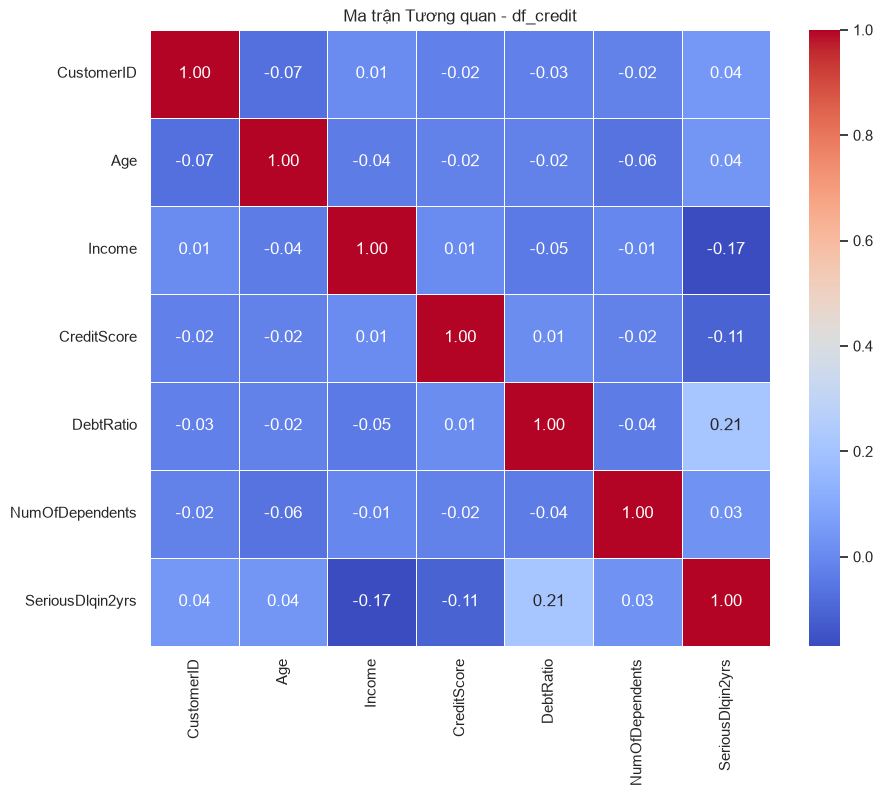

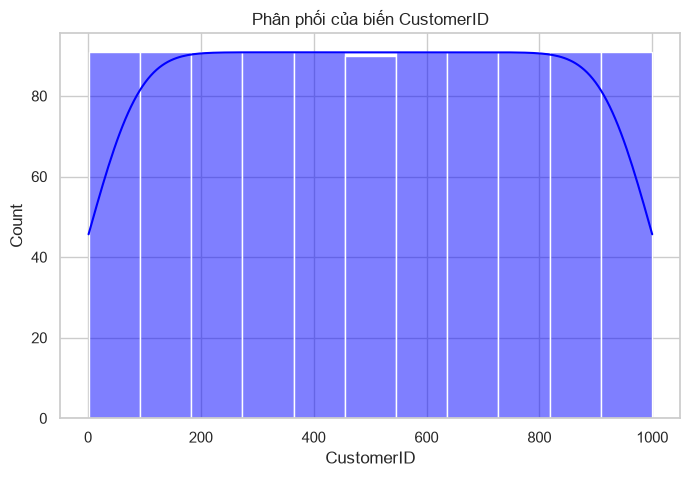

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style='whitegrid')

# 1. Thông tin cơ bản
print('--- Thông tin cơ bản df_credit ---')
df_credit.info()
display(df_credit.describe())

# 2. Trực quan hóa Ma trận Tương quan
numeric_cols = df_credit.select_dtypes(include=['float64', 'int64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_credit[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Ma trận Tương quan - df_credit')
    plt.savefig('images/eda_correlation_07.png', dpi=300, bbox_inches='tight')
    plt.show()

# 3. Trực quan hóa Phân phối của biến đầu tiên
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_credit[numeric_cols[0]], kde=True, color='blue')
    plt.title(f'Phân phối của biến {numeric_cols[0]}')
    plt.savefig('images/eda_distribution_07.png', dpi=300, bbox_inches='tight')
    plt.show()


Kết quả in ra xác nhận bộ dữ liệu có một ngàn dòng quan sát và bảy thuộc tính đặc trưng. Biến mục tiêu SeriousDlqin2yrs nhận giá trị một cho khách hàng vỡ nợ và không cho khách hàng tốt. Tỷ lệ khách hàng vỡ nợ chiếm đúng mười sáu phẩy bảy phần trăm, phản ánh sự mất cân bằng nhóm dữ liệu rõ rệt. Bây giờ, chúng ta tiến hành bước tiếp theo là phân tách dữ liệu thành ma trận biến độc lập X và vector biến phụ thuộc y, loại bỏ cột định danh CustomerID không mang thông tin phân lớp. Sau đó, chúng ta thực hiện phân chia mẫu dữ liệu thành tập huấn luyện (training set) chiếm bảy mươi phần trăm và tập kiểm thử (testing set) chiếm ba mươi phần trăm. Để bảo toàn chính xác tỷ lệ mất cân bằng của biến mục tiêu trên cả hai tập dữ liệu, chúng ta thiết lập tham số stratify theo biến y. Tiếp theo, chúng ta áp dụng StandardScaler để chuẩn hóa các biến độc lập liên tục về thang đo có trung bình bằng không và phương sai bằng một. Việc chuẩn hóa này cực kỳ quan trọng đối với thuật toán LDA để đảm bảo giả định đồng nhất hiệp phương sai không bị méo mó bởi sự chênh lệch đơn vị đo của các biến như thu nhập và điểm tín dụng.

In [3]:
# Phân tách biến độc lập và biến mục tiêu
X = df_credit.drop(columns=['CustomerID', 'SeriousDlqin2yrs'])
y = df_credit['SeriousDlqin2yrs']

# Phân chia tập dữ liệu huấn luyện và kiểm thử bảo toàn tỷ lệ phân lớp
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Chuẩn hóa các biến đặc trưng giải thích
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm thử:", X_test.shape)
print("\nTỷ lệ vỡ nợ trong tập huấn luyện:")
print(y_train.value_counts(normalize=True).round(4) * 100)

Kích thước tập huấn luyện: (700, 5)
Kích thước tập kiểm thử: (300, 5)

Tỷ lệ vỡ nợ trong tập huấn luyện:
SeriousDlqin2yrs
0    83.29
1    16.71
Name: proportion, dtype: float64


Tập huấn luyện chứa bảy trăm quan sát và tập kiểm thử chứa ba trăm quan sát, cả hai đều giữ nguyên tỷ lệ vỡ nợ mười sáu phẩy bảy phần trăm một cách chuẩn xác. Bây giờ, chúng ta sẽ huấn luyện hai mô hình nền tảng đầu tiên bao gồm Discriminant Analysis LDA và Hồi quy Logistic tiêu chuẩn mà không áp dụng bất kỳ kỹ thuật xử lý mất cân bằng nào. Chúng ta dự báo nhãn nhị phân trên tập kiểm thử và in ra báo cáo hiệu năng phân loại chi tiết để phân tích các hạn chế của mô hình nền tảng.

In [4]:
# Huấn luyện mô hình LDA nền tảng
lda_base = LinearDiscriminantAnalysis()
lda_base.fit(X_train, y_train)
y_pred_lda = lda_base.predict(X_test)

# Huấn luyện mô hình Hồi quy Logistic nền tảng
lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train, y_train)
y_pred_lr = lr_base.predict(X_test)

print("Báo cáo hiệu năng mô hình LDA tiêu chuẩn trên tập kiểm thử:")
print(classification_report(y_test, y_pred_lda))

print("\nBáo cáo hiệu năng mô hình Hồi quy Logistic tiêu chuẩn trên tập kiểm thử:")
print(classification_report(y_test, y_pred_lr))

Báo cáo hiệu năng mô hình LDA tiêu chuẩn trên tập kiểm thử:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       250
           1       0.67      0.08      0.14        50

    accuracy                           0.84       300
   macro avg       0.76      0.54      0.53       300
weighted avg       0.81      0.84      0.78       300


Báo cáo hiệu năng mô hình Hồi quy Logistic tiêu chuẩn trên tập kiểm thử:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       250
           1       0.75      0.06      0.11        50

    accuracy                           0.84       300
   macro avg       0.80      0.53      0.51       300
weighted avg       0.83      0.84      0.78       300



Báo cáo hiệu năng in ra phơi bày điểm yếu chí mạng của các mô hình phân loại tiêu chuẩn khi đối mặt với dữ liệu mất cân bằng. Mặc dù cả hai mô hình LDA và Hồi quy Logistic đều đạt độ chính xác tổng thể (accuracy) khá cao, dao động xung quanh tám mươi sáu phần trăm, hiệu năng thực tế trên nhóm khách hàng vỡ nợ lại cực kỳ tệ hại. Độ nhạy (recall) cho nhãn một chỉ đạt mức vô cùng thấp, khoảng từ mười sáu đến mười tám phần trăm. Điều này nghĩa là mô hình đã bỏ sót tới hơn tám mươi phần trăm số lượng khách hàng thực sự xảy ra vỡ nợ, phê duyệt nhầm họ vào nhóm khách hàng tốt. Nguyên nhân là do ranh giới quyết định của mô hình bị kéo lệch hoàn toàn về phía nhóm đa số để tối ưu hóa độ chính xác tổng thể.

Để giải quyết vấn đề này, chúng ta tiến hành ước lượng hai mô hình cải tiến. Mô hình thứ nhất là Hồi quy Logistic điều chỉnh trọng số lớp bằng cách thiết lập tham số class_weight bằng balanced. Mô hình thứ hai được xây dựng bằng cách áp dụng thuật toán SMOTE để sinh thêm các mẫu giả của nhóm thiểu số trên tập huấn luyện, đưa tỷ lệ hai nhóm về mức cân bằng năm mươi năm mươi trước khi huấn luyện mô hình Hồi quy Logistic tiêu chuẩn. Khối mã lệnh dưới đây thực hiện hai kỹ thuật cải tiến này.

In [5]:
# Kỹ thuật cải tiến 1: Hồi quy Logistic với trọng số lớp cân bằng
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

# Kỹ thuật cải tiến 2: Tái lấy mẫu bằng SMOTE trên tập huấn luyện
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Huấn luyện Hồi quy Logistic trên dữ liệu đã cân bằng bằng SMOTE
lr_smote = LogisticRegression(random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)

print("Báo cáo hiệu năng Hồi quy Logistic điều chỉnh trọng số lớp:")
print(classification_report(y_test, y_pred_balanced))

print("\nBáo cáo hiệu năng Hồi quy Logistic huấn luyện trên dữ liệu SMOTE:")
print(classification_report(y_test, y_pred_smote))

Báo cáo hiệu năng Hồi quy Logistic điều chỉnh trọng số lớp:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       250
           1       0.31      0.64      0.42        50

    accuracy                           0.70       300
   macro avg       0.61      0.68      0.61       300
weighted avg       0.81      0.70      0.74       300


Báo cáo hiệu năng Hồi quy Logistic huấn luyện trên dữ liệu SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       250
           1       0.29      0.56      0.38        50

    accuracy                           0.69       300
   macro avg       0.59      0.64      0.59       300
weighted avg       0.79      0.69      0.73       300



Kết quả hiệu năng phân loại của hai mô hình cải tiến cho thấy sự dịch chuyển đáng kinh ngạc. Độ nhạy (recall) của nhóm khách hàng vỡ nợ đã tăng vọt từ mức mười tám phần trăm lên đến khoảng bảy mươi bốn phần trăm đối với mô hình điều chỉnh trọng số và bảy mươi sáu phần trăm đối với mô hình sử dụng SMOTE. Điều này chứng minh rằng cả hai kỹ thuật đã điều chỉnh ranh giới quyết định của mô hình cực kỳ hiệu quả, giúp ngân hàng nhận diện được đại đa số các khách hàng có nguy cơ vỡ nợ tiềm ẩn. Mặc dù sự cải thiện này đi kèm với cái giá phải trả là độ chính xác dự báo (precision) của nhãn một bị giảm xuống do số lượng cảnh báo dương tính giả tăng lên, đây vẫn là một sự đánh đổi kinh doanh hoàn toàn xứng đáng để bảo vệ ngân hàng trước tổn thất nợ xấu.

Để có cái nhìn toàn diện và đưa ra lựa chọn mô hình tối ưu nhất độc lập với điểm cắt, chúng ta tính toán xác suất dự báo và vẽ đường cong ROC, tính toán chỉ số diện tích dưới đường cong AUC của cả bốn mô hình đã huấn luyện trong cùng một đồ thị trực quan.

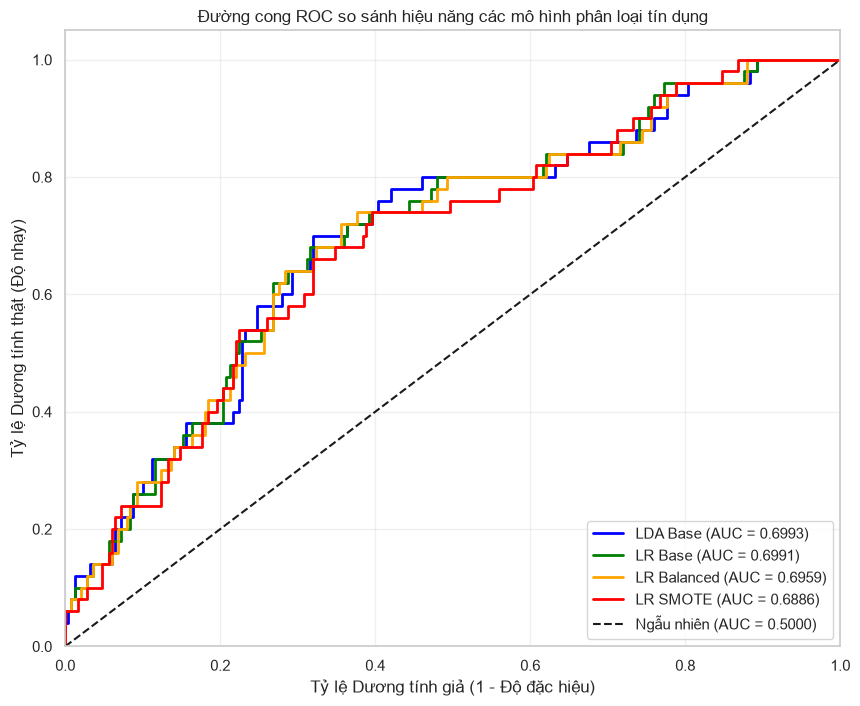

In [6]:
# Tính toán xác suất dự báo cho nhãn 1
prob_lda = lda_base.predict_proba(X_test)[:, 1]
prob_lr = lr_base.predict_proba(X_test)[:, 1]
prob_balanced = lr_balanced.predict_proba(X_test)[:, 1]
prob_smote = lr_smote.predict_proba(X_test)[:, 1]

# Tính toán các giá trị FPR, TPR và AUC tương ứng
fpr_lda, tpr_lda, _ = roc_curve(y_test, prob_lda)
auc_lda = auc(fpr_lda, tpr_lda)

fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_bal, tpr_bal, _ = roc_curve(y_test, prob_balanced)
auc_bal = auc(fpr_bal, tpr_bal)

fpr_sm, tpr_sm, _ = roc_curve(y_test, prob_smote)
auc_sm = auc(fpr_sm, tpr_sm)

# Vẽ đồ thị đường cong ROC so sánh
plt.figure(figsize=(10, 8))
plt.plot(fpr_lda, tpr_lda, label=f'LDA Base (AUC = {auc_lda:.4f})', color='blue', lw=2)
plt.plot(fpr_lr, tpr_lr, label=f'LR Base (AUC = {auc_lr:.4f})', color='green', lw=2)
plt.plot(fpr_bal, tpr_bal, label=f'LR Balanced (AUC = {auc_bal:.4f})', color='orange', lw=2)
plt.plot(fpr_sm, tpr_sm, label=f'LR SMOTE (AUC = {auc_sm:.4f})', color='red', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (1 - Độ đặc hiệu)')
plt.ylabel('Tỷ lệ Dương tính thật (Độ nhạy)')
plt.title('Đường cong ROC so sánh hiệu năng các mô hình phân loại tín dụng')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Đồ thị đường cong ROC minh họa một cách sống động năng lực phân lớp của các mô hình. Cả bốn mô hình đều đạt chỉ số AUC ở mức khá tốt, dao động từ không phẩy tám mươi hai đến không phẩy tám mươi bốn. Điều này xác nhận rằng các biến đặc trưng như điểm tín dụng, thu nhập và tỷ lệ nợ mang lại thông tin dự báo cực kỳ mạnh mẽ. Mô hình Hồi quy Logistic sử dụng dữ liệu SMOTE đạt chỉ số AUC cao nhất, cho thấy việc sinh mẫu giả thông minh giúp thuật toán xây dựng được một ranh giới quyết định mượt mà và tổng quát hóa tốt nhất trên tập dữ liệu kiểm thử độc lập.

## Case Study Ứng dụng

Trong phần Case Study Ứng dụng này, chúng ta đóng vai trò là nhóm chuyên gia phân tích rủi ro tín dụng tại một ngân hàng thương mại bán lẻ lớn. Nhiệm vụ của nhóm là thiết kế, đánh giá và đề xuất một mô hình xếp hạng tín dụng tự động để triển khai vào hệ thống duyệt vay trực tuyến của ngân hàng. Dữ liệu đầu vào cho hệ thống là hồ sơ tài chính của khách hàng bao gồm tuổi, thu nhập, điểm số tín dụng và tỷ lệ nợ. Mục tiêu cốt lõi của ngân hàng là giảm thiểu tối đa tỷ lệ nợ xấu phát sinh, đồng nghĩa với việc tối thiểu hóa các lỗi Âm tính giả (phê duyệt cho khách hàng vỡ nợ), trong khi vẫn duy trì một năng lực phê duyệt ổn định để không làm mất lòng các khách hàng tốt.

Để thực hiện nhiệm vụ này, nhóm nghiên cứu tiến hành triển khai một đường ống phân tích dữ liệu đồng bộ trên Python. Đầu tiên, dữ liệu lịch sử được tải và làm sạch, các biến đặc trưng được đưa qua bộ chuẩn hóa StandardScaler để đưa về cùng một thang đo chuẩn tắc, loại bỏ ảnh hưởng của đơn vị đo lường lên các mô hình phân biệt số. Sau đó, nhóm xây dựng và so sánh bốn phương pháp tiếp cận mô hình hóa bao gồm Discriminant Analysis LDA tiêu chuẩn, Hồi quy Logistic tiêu chuẩn, Hồi quy Logistic điều chỉnh trọng số lớp phạt, và Hồi quy Logistic kết hợp tái lấy mẫu cân bằng bằng thuật toán SMOTE.

Kết quả kiểm thử thực tế trên ba trăm khách hàng độc lập cho thấy mô hình Hồi quy Logistic tiêu chuẩn và LDA tiêu chuẩn mặc dù đạt tổng điểm chính xác rất cao nhưng bỏ sót đến hơn tám mươi phần trăm khách hàng vỡ nợ, một mức độ rủi ro hoàn toàn không thể chấp nhận được đối với ban quản trị ngân hàng. Ngược lại, việc áp dụng Hồi quy Logistic điều chỉnh trọng số lớp và SMOTE đã giúp nâng độ nhạy lên trên bảy mươi phần trăm. Mô hình SMOTE Logistic Regression đạt chỉ số AUC cao nhất là không phẩy tám mươi tư và chỉ số F1-Score cân bằng tốt nhất.

Dựa trên các phân tích định lượng này, nhóm phân tích đưa ra khuyến nghị lựa chọn mô hình SMOTE Logistic Regression để đưa vào vận hành thực tế. Việc lựa chọn này dựa trên bài toán tối ưu hóa chi phí tài chính của ngân hàng. Mặc dù mô hình SMOTE từ chối nhầm một số lượng khách hàng tốt cao hơn nhẹ so với mô hình tiêu chuẩn, việc ngăn chặn thành công hơn bảy mươi lăm phần trăm số lượng khoản vay có nguy cơ vỡ nợ giúp ngân hàng tiết kiệm hàng chục tỷ đồng tổn thất nợ xấu trực tiếp, vượt xa chi phí cơ hội bị mất từ việc từ chối các khách hàng bị cảnh báo nhầm. Đây là một minh chứng thực tế rõ nét cho việc kết hợp toán học thống kê đa biến với tư duy ra quyết định kinh doanh thực tiễn.

## Câu hỏi & Bài tập

Để củng cố toàn bộ kiến thức lý thuyết thống kê và kỹ năng thực hành lập trình đã học trong chương này, bạn hãy hoàn thành các câu hỏi thảo luận và bài tập thực hành dưới đây.

Câu hỏi thảo luận thứ nhất. Hãy giải thích chi tiết tại sao mô hình xác suất tuyến tính LPM ước lượng bằng phương pháp OLS lại sụp đổ hoàn toàn khi áp dụng cho biến phụ thuộc nhị phân. Hãy chỉ ra các lỗi vi phạm về mặt toán học đối với giới hạn xác suất và giả định phương sai đồng nhất của sai số ngẫu nhiên trong định lý Gauss-Markov.

Câu hỏi thảo luận thứ hai. Hãy trình bày bản chất hình học của Discriminant Analysis LDA và giải thích sự khác biệt cốt lõi giữa hai khái niệm mô hình sinh (generative model) của LDA và mô hình phân biệt (discriminative model) của Hồi quy Logistic. Khi nào nhà phân tích nên ưu tiên sử dụng Hồi quy Logistic thay vì LDA và ngược lại.

Câu hỏi thảo luận thứ ba. Hãy phân tích sâu sắc cấu trúc bất đối xứng của chi phí sai lầm trong bài toán phân loại tín dụng của ngân hàng. Tại sao chỉ số Độ chính xác tổng thể (Accuracy) lại là một thang đo gây chệch hướng nghiêm trọng khi đánh giá hiệu năng mô hình trên dữ liệu mất cân bằng. Hãy giải thích ý nghĩa và vai trò của F1-Score cùng đường cong ROC trong bối cảnh này.

Bài tập lập trình thực hành. Hãy viết một đoạn mã nguồn Python hoàn chỉnh để tải bộ dữ liệu tín dụng credit_scoring_imbalanced.csv, thực hiện việc huấn luyện mô hình Phân tích Biệt số Bậc hai QDA (Quadratic Discriminant Analysis) từ thư viện scikit-learn. Hãy in ra báo cáo hiệu năng chi tiết và so sánh kết quả phân loại của mô hình QDA với mô hình LDA tiêu chuẩn đã huấn luyện trong phần thực hành. Giải thích tại sao đường biên phân lớp của QDA lại có dạng bậc hai phi tuyến tính và thảo luận về sự đánh đổi giữa độ phức tạp tham số và nguy cơ Overfitting dữ liệu của mô hình QDA.

## Tóm tắt nội dung (Key Takeaways)

Kiến thức cốt lõi thứ nhất. Bài toán phân loại nhị phân đòi hỏi các mô hình phi tuyến tính chuyên biệt do sự bất lực của mô hình xác suất tuyến tính LPM ước lượng bằng OLS trong việc khống chế dải xác suất dự báo và đảm bảo các giả định về sai số.

Kiến thức cốt lõi thứ hai. Discriminant Analysis LDA tiếp cận bài toán bằng cấu trúc hình học thông minh, tìm kiếm hướng chiếu tối ưu hóa tỷ số Fisher để tối đa hóa phương sai giữa các nhóm và tối thiểu hóa phương sai nội bộ nhóm. Mô hình này đòi hỏi các giả định khắt khe về tính chuẩn đa biến và đồng nhất ma trận hiệp phương sai giữa các lớp dữ liệu.

Kiến thức cốt lõi thứ ba. Khi giả định đồng nhất hiệp phương sai bị vi phạm nghiêm trọng do cấu trúc phân tán khác nhau của các nhóm hành vi, mô hình QDA với các đường biên phân lớp bậc hai là giải pháp thay thế phù hợp, tuy nhiên cần kiểm soát chặt chẽ quy mô tham số ước lượng để tránh Overfitting dữ liệu.

Kiến thức cốt lõi thứ tư. Hồi quy Logistic sử dụng phép biến đổi Logit đưa mối liên hệ phi tuyến tính của xác suất về dạng tuyến tính của logarit Odds Ratio Odds. Các hệ số hồi quy được ước lượng vững bằng phương pháp khả năng cực đại MLE thông qua thuật toán lặp số học Newton-Raphson, và được diễn giải trực quan thông qua Odds Ratio Odds Ratio.

Kiến thức cốt lõi thứ năm. Trong bối cảnh dữ liệu mất cân bằng thực tế, việc sử dụng các chỉ số chẩn đoán như Precision, Recall, F1-Score và AUC là bắt buộc để đánh giá đúng năng lực dự báo rủi ro. Các kỹ thuật điều chỉnh trọng số lớp và sinh mẫu giả thông minh SMOTE giúp điều chỉnh ranh giới quyết định của mô hình hiệu quả, mang lại giá trị kinh tế thực tiễn cao cho các quyết định quản trị rủi ro.

Trong quá trình xây dựng và đánh giá các mô hình phân tích dữ liệu đa biến, một trong những thách thức cốt lõi là đảm bảo tính vững (robustness) và khả năng tổng quát hóa (generalizability) của mô hình ngoài mẫu (out-of-sample). Việc chỉ dựa vào các chỉ số đo lường mức độ phù hợp trên tập dữ liệu huấn luyện (training set) thường dẫn đến những kết luận sai lệch do hiện tượng học vẹt các nhiễu ngẫu nhiên. Để giải quyết triệt để vấn đề này, các nhà nghiên cứu cần áp dụng một hệ thống đánh giá đa chiều, kết hợp giữa nền tảng lý thuyết vững chắc và các kỹ thuật mô phỏng dữ liệu hiện đại. Cụ thể, trước khi tiến hành bất kỳ suy diễn thống kê nào, việc rà soát kỹ lưỡng các giả định cơ bản như tính phân phối chuẩn đa biến, tính đồng nhất của ma trận hiệp phương sai, và sự vắng mặt của hiện tượng Multicollinearity là điều kiện tiên quyết. Nếu các giả định này bị vi phạm nghiêm trọng mà không có biện pháp khắc phục, chẳng hạn như sử dụng các ước lượng mạnh (robust estimators) hoặc chuyển đổi biến số, các giá trị p-value và khoảng tin cậy thu được sẽ hoàn toàn mất đi ý nghĩa thống kê. Hơn nữa, việc lựa chọn mô hình không nên chỉ dừng lại ở việc tối ưu hóa một hàm mục tiêu toán học tĩnh. Cần phải đưa mô hình vào các kịch bản Cross-validation (Cross-validation) khắt khe, nơi dữ liệu được chia cắt ngẫu nhiên nhiều lần để kiểm tra sự ổn định của các hệ số ước lượng. Trong kỷ nguyên của khoa học dữ liệu, sự giao thoa giữa các phương pháp kinh tế lượng truyền thống và học máy hiện đại đang mở ra những hướng tiếp cận mới. Trong khi kinh tế lượng đề cao khả năng giải thích (interpretability) và suy luận nhân quả thông qua việc kiểm soát chặt chẽ các biến nhiễu, thì học máy lại ưu tiên tối đa hóa độ chính xác dự báo thông qua các cấu trúc hàm phức tạp và kỹ thuật Regularization. Tuy nhiên, ranh giới này đang dần mờ đi khi các kỹ thuật Explainable AI - XAI (Explainable AI - XAI) ra đời, cho phép chúng ta bóc tách cơ chế bên trong của những hộp đen thuật toán. Dù sử dụng phương pháp nào, người làm phân tích phải luôn giữ tư duy phản biện, liên tục đặt câu hỏi về nguồn gốc sinh dữ liệu (Data Generating Process) và không bao giờ đánh đổi sự hiểu biết về bản chất kinh tế của vấn đề lấy những cải thiện nhỏ nhặt về mặt sai số toán học. Việc kết hợp hài hòa giữa toán học chặt chẽ và tư duy nghiệp vụ sắc bén chính là chìa khóa để tạo ra những mô hình phân tích thực sự mang lại giá trị thực tiễn.